# Aplicación de un modelo LSTM (Long Short-Term Memory) multivariable para la predicción del consumo eléctrico a corto plazo en alimentadores de distribución urbanos y rurales de la provincia de Tungurahua, utilizando datos históricos de 2016–2025 
## Pronóstico de Demanda a Corto Plazo (STLF) — EEASA
## Trayectoria Completa: Preprocesamiento, Desarrollo Metodológico (v1→v4) y Modelo Final V4 a Horizonte 1h

**Maestría en Inteligencia Artificial Aplicada — UIDE.** 5 alimentadores (ALIN, ALUC, ALUR, ALRA,
ALRG), Empresa Eléctrica Ambato S.A. (EEASA), Tungurahua.

---

### Qué documenta este notebook

| Parte | Contenido |
|---|---|
| A | Preprocesamiento: tipos de medidor, limpieza, hallazgos que motivaron cada decisión |
| B | Desarrollo metodológico v1→v2→v3→v4 — (horizonte=4), solo para un alimentador (ALRG) |
| C | V1 y V4 entrenados para 1h — los 5 alimentadores |
| D | Comparación final: V4 vs. clásicos (persistencia, media móvil, regresión, ARIMA) |
| F | Decisiones de diseño validadas, incluyendo una hipótesis descartada con evidencia |
| G | Síntesis del modelo final por alimentador |
| H | Síntesis narrativa por alimentador |
| I | Verificación de umbrales: teórico vs. práctico |
| K | Ejemplos de predicción — V1 vs. V4, los 5 alimentadores |

**Todas las versiones (v1 a v4) se entrenan y evalúan nativamente a horizonte=4 pasos (1 hora),**
ventana=96 pasos (24h de historial). El desarrollo metodológico completo (v1→v2→v3→v4) se
documenta sobre ALRG (Parte B); **v4 (aprendizaje de residuos, regularización estándar) es el
modelo final en los 5 alimentadores**, incluyendo ALIN — una variante con regularización reforzada
se probó específicamente para ALIN (Parte F) y no mostró ninguna mejora, así que no forma parte del
pipeline final.

### Archivos de entrada necesarios

| Archivo | Para qué |
|---|---|
| `dataset_limpio_<CODIGO>.csv` (×5) | Base para reconstruir features y entrenar |
| `reporte_calidad_<CODIGO>.json` (×5, opcional) | Calidad de datos, Parte A |
| `tabla10_corregida_1h.csv` | Métricas de los modelos clásicos (persistencia, media móvil, regresión, ARIMA), ya evaluados nativamente a 1h |
| `lstm_v#_<CODIGO>_best.keras` (ALIN, ALUC, ALUR, ALRA, ALRG) | no entrenar V1 hasta la V4 |


In [1]:
# ============================================================
# Imports
# ============================================================

!pip install holidays --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, LSTM, Dense, Dropout, BatchNormalization,
                                      Conv1D, LayerNormalization, Lambda, Concatenate, Flatten)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2, l1_l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import holidays
import json
import warnings, gc, time
from pathlib import Path
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
np.random.seed(42); tf.random.set_seed(42)
C = {'gris': '#7f7f7f', 'naranja': '#ff7f0e', 'azul': '#1f77b4', 'morado': '#9467bd', 'verde': '#2ca02c'}

# ============================================================
# REENTRENAR_TODO — interruptor maestro. En False (default), cada
# celda de entrenamiento (Parte B, C.2, C.3.3) busca primero si el
# .keras correspondiente YA existe (en /kaggle/input, re-adjuntado
# como dataset, o en /kaggle/working si es la misma sesión) y, si lo
# encuentra, SOLO CARGA e infiere — no vuelve a entrenar. Si no lo
# encuentra (o si REENTRENAR_TODO=True), entrena desde cero como
# antes. Así se evita gastar GPU en modelos que ya están entrenados.
# ============================================================
REENTRENAR_TODO = False

def buscar_archivo_real(patron):
    """Devuelve la primera ruta que sea un ARCHIVO real (no carpeta) que matchee el patrón.
    Busca en /kaggle/input (datasets adjuntados) Y en /kaggle/working (checkpoints ya
    generados en esta misma sesión) — en ese orden. Si encuentra una carpeta con ese
    nombre (rareza de montaje de Kaggle), busca adentro."""
    candidatos_base = []
    if Path('/kaggle/input').exists():
        candidatos_base.append(Path('/kaggle/input'))
    if Path('/kaggle/working').exists():
        candidatos_base.append(Path('/kaggle/working'))
    if not candidatos_base:
        candidatos_base.append(Path('.'))

    for base in candidatos_base:
        for candidato in base.rglob(patron):
            if candidato.is_file():
                return candidato
            if candidato.is_dir():
                internos = list(candidato.rglob('*.csv')) + list(candidato.rglob('*.csv.gz')) + list(candidato.rglob('*.json'))
                if internos:
                    return internos[0]
    return None


RUTA_DATASET = None
_c = buscar_archivo_real('dataset_limpio_ALIN.csv')
if _c: RUTA_DATASET = _c.parent
if RUTA_DATASET is None: RUTA_DATASET = Path('.')  # AJUSTAR

RUTA_RESULTADOS = None
_c = buscar_archivo_real('tabla10_corregida_1h.csv')
if _c: RUTA_RESULTADOS = _c.parent
if RUTA_RESULTADOS is None: RUTA_RESULTADOS = RUTA_DATASET  # AJUSTAR

RUTA_MODELOS = None
_c = buscar_archivo_real('lstm_v4_ALIN_best.keras')
if _c: RUTA_MODELOS = _c.parent
if RUTA_MODELOS is None: RUTA_MODELOS = RUTA_RESULTADOS  # AJUSTAR

RUTA_SALIDAS = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path('.')

print(f'📂 RUTA_DATASET: {RUTA_DATASET}')
print(f'📂 RUTA_RESULTADOS: {RUTA_RESULTADOS}')
print(f'📂 RUTA_MODELOS: {RUTA_MODELOS}')
print(f'📂 RUTA_SALIDAS: {RUTA_SALIDAS}')
print(f'🔁 REENTRENAR_TODO: {REENTRENAR_TODO} ({"se reentrena todo desde cero" if REENTRENAR_TODO else "se cargan los .keras ya entrenados cuando existan"})')


📂 RUTA_DATASET: /kaggle/input/datasets/dpou45/eeasa-tensores-lstm-parte1
📂 RUTA_RESULTADOS: /kaggle/input/datasets/dpou45/input-final-titulacion
📂 RUTA_MODELOS: /kaggle/input/datasets/dpou45/input-final-titulacion
📂 RUTA_SALIDAS: /kaggle/working
🔁 REENTRENAR_TODO: False (se cargan los .keras ya entrenados cuando existan)


In [2]:
ALIMENTADORES = [
    {'codigo': 'ALIN', 'descripcion': 'Industrial',                       'umbral_practico': 12.0, 'umbral_teorico': np.nan, 'cv': 1.039},  # sin categoría teórica: el anteproyecto solo define umbral urbano/rural, no industrial
    {'codigo': 'ALUC', 'descripcion': 'Urbano Residencial-Comercial',     'umbral_practico': 9.0,  'umbral_teorico': 5.0,  'cv': 0.884},
    {'codigo': 'ALUR', 'descripcion': 'Urbano Residencial',               'umbral_practico': 12.0, 'umbral_teorico': 5.0,  'cv': 1.043},
    {'codigo': 'ALRA', 'descripcion': 'Rural Residencial-Agrícola',       'umbral_practico': 8.0,  'umbral_teorico': 8.0,  'cv': 0.812},
    {'codigo': 'ALRG', 'descripcion': 'Rural Residencial-Ganadero',       'umbral_practico': 8.0,  'umbral_teorico': 8.0,  'cv': 0.933},
]
LISTA_FEATURES = [
    'kw_activa', 'kvar_reactiva', 'fp_calculado',
    'paso_dia_sin', 'paso_dia_cos', 'dow_sin', 'dow_cos',
    'mes_sin', 'mes_cos', 'semana_sin', 'semana_cos',
    'es_fin_semana', 'es_lunes', 'es_viernes', 'es_feriado_ec', 'flag_gap',
    'kw_lag_4', 'kw_lag_8', 'kw_lag_96', 'kw_lag_192', 'kw_lag_672',
    'kw_media_24h', 'kw_std_24h', 'kw_max_24h', 'kw_min_24h', 'kw_rango_24h',
]
IDX_KW = LISTA_FEATURES.index('kw_activa')
VENTANA_1H = 96     # 24 horas de historial
HORIZONTE_1H = 4    # 1 hora — horizonte del anteproyecto

print(f'✅ Configuración: ventana={VENTANA_1H} pasos (24h), horizonte={HORIZONTE_1H} pasos (1h) — en todas las versiones')
print(f'Nota: ALIN no tiene umbral teórico (sin categoría industrial en el proyecto)')


✅ Configuración: ventana=96 pasos (24h), horizonte=4 pasos (1h) — en todas las versiones
Nota: ALIN no tiene umbral teórico (sin categoría industrial en el proyecto)


## PARTE A — Preprocesamiento y Limpieza de Datos

*Fuente: `pipeline_datos_reales_eeasa.ipynb`,*

### A.1 — Heterogeneidad de medidores SCADA

Los archivos exportados por los medidores EEASA presentan tres heterogeneidades que se debieron resolver antes de entrenar cualquier modelo:

| Problema real detectado | Estrategia de solución |
|---|---|
| Medidor Tipo A: 17 variables (trifásico completo) | Extraer núcleo + calcular derivadas |
| Medidor Tipo B: 5 variables (básico) | Usar directamente el núcleo |
| Medidor Tipo C: 9 variables (alternativo) | Columna de tensión promedio |
| Mes en cero por mantenimiento/cambio de equipo | Detectar y marcar como gap permanente |
| Timestamp perdido en archivo con gap | Reconstruir desde el nombre del archivo |
| 3 formatos de fecha distintos entre archivos | Parser universal multi-formato |
| Registros duplicados o faltantes | Reindexado a 15 min exactos |

**Reglas de imputación (Sección 6):** huecos ≤ 2 horas (8 pasos) se interpolan linealmente; huecos
mayores se dejan como `NaN` y se excluyen del entrenamiento — no se fabrican datos falsos. Los
outliers se **marcan** con un flag, nunca se eliminan (para no perder información real de picos de
demanda).

### A.2 — Reporte de Calidad por Alimentador (los 5, datos reales)

In [3]:
filas_calidad = []
for ali in ALIMENTADORES:
    codigo = ali['codigo']
    ruta = buscar_archivo_real(f'reporte_calidad_{codigo}.json')
    if ruta is None:
        print(f'info: reporte_calidad_{codigo}.json no encontrado - se omite (opcional)')
        continue
    with open(ruta) as f:
        rc = json.load(f)
    cal = rc.get('calidad', rc)  # estructura real: {"alimentador":..., "calidad": {...}}
    filas_calidad.append({
        'Alimentador': codigo,
        'Registros esperados': cal.get('n_esperados'),
        'Completitud (%)': cal.get('completitud_pct'),
        'Huecos comunicación': cal.get('n_huecos_comunicacion'),
        'Huecos grandes sin imputar': cal.get('n_huecos_grandes_sin_imputar'),
        'Outliers marcados': cal.get('n_outliers_marcados'),
        'kW media': cal.get('kw_media'),
        'kW std': cal.get('kw_std'),
        'CV (std/media)': round(cal['kw_std'] / cal['kw_media'], 3) if cal.get('kw_media') else None,
    })

if filas_calidad:
    tabla_calidad = pd.DataFrame(filas_calidad)
    print(tabla_calidad.to_string(index=False))
else:
    print('info: ningún reporte_calidad_<CODIGO>.json disponible - se continúa con el resto del notebook.')


Alimentador  Registros esperados  Completitud (%)  Huecos comunicación  Huecos grandes sin imputar  Outliers marcados  kW media  kW std  CV (std/media)
       ALIN               350688            99.04                 3436                           7               3503    163.11  169.50           1.039
       ALUC               350688            98.69                 4646                           5                161    484.21  428.24           0.884
       ALUR               350688            97.64                 8501                           7               1319    451.43  470.75           1.043
       ALRA               350688            98.07                 7213                           7                879    565.87  459.59           0.812
       ALRG               350688            96.80                11243                           9                 69    463.78  432.83           0.933


#### El CV (coeficiente de variación)

El **coeficiente de variación** es la razón entre la desviación estándar y la media de una serie:

```
CV = kW_std / kW_media
```

El CV es **adimensional**: normaliza la dispersión respecto al propio nivel de la serie. Esto permite comparar qué tan "volátil" es cada alimentador *en relación a su propia escala*, sin que el resultado esté sesgado por cuál consume más en términos absolutos.

- **CV < 1**: la dispersión es menor que la media — serie relativamente estable, con una demanda
  base predecible sobre la que se dan variaciones moderadas.
- **CV ≈ 1**: la dispersión es del mismo orden que la media — la serie tiene tramos donde el valor
  cae a una fracción pequeña de su propio promedio (picos y valles pronunciados).
- **CV > 1**: la desviación estándar *supera* a la media — la serie es altamente volátil relativa a
  su propio nivel.

Los dos rurales (ALRA, ALRG) tienen CV moderado para su categoría, los dos urbanos (ALUC, ALUR) tienen CV notablemente más alto de lo que se asumiría para demanda urbana y ALIN su CV es el segundo más alto de los 5.


### A.3 — Visualización de Calidad (los 5 Alimentadores)

ALIN (Industrial) — Shape: (350688, 11)  |  Rango: 2016-01-01 00:15:00 a 2026-01-01 00:00:00


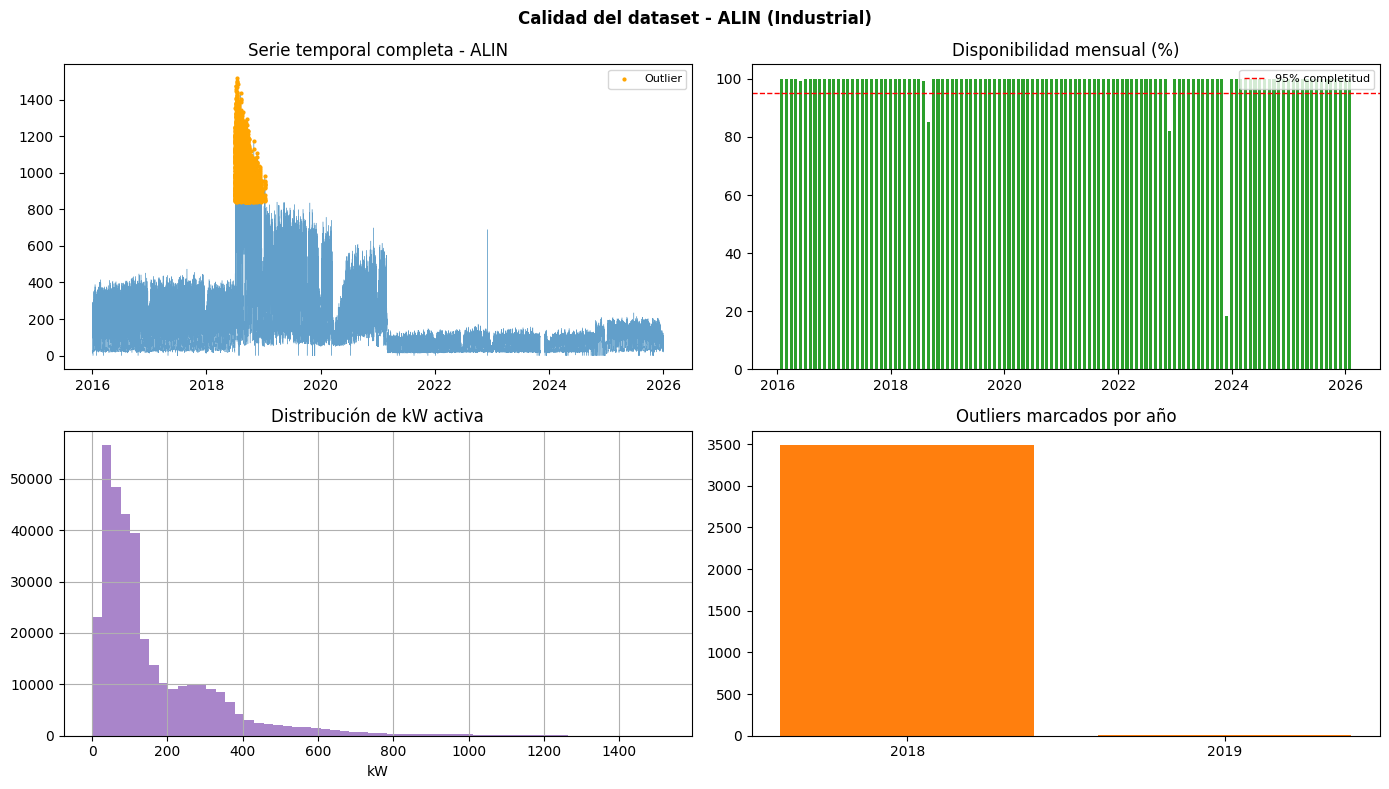


**Conclusión — ALIN (Industrial):**
  - Completitud: 99.04%  |  CV (std/media): 1.039  (este valor es el que calibra el umbral práctico de ALIN en la Parte I)
  - Los outliers se concentran en [2018, 2019], coincidiendo con [2019] — evidencia directa (no solo de ALRG) del régimen atípico 2019-2021 excluido del entrenamiento (fila 2, A.5).

ALUC (Urbano Residencial-Comercial) — Shape: (350688, 11)  |  Rango: 2016-01-01 00:15:00 a 2026-01-01 00:00:00


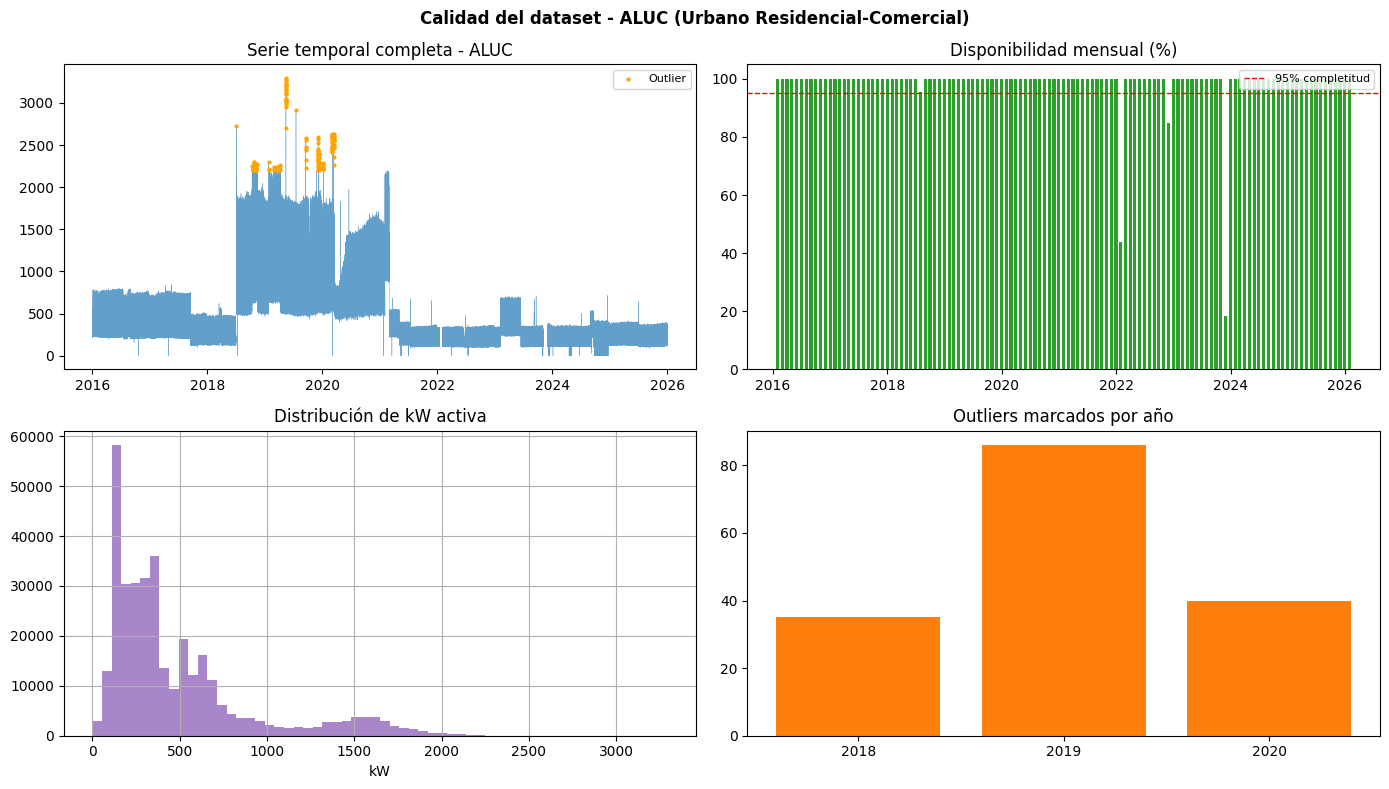


**Conclusión — ALUC (Urbano Residencial-Comercial):**
  - Completitud: 98.69%  |  CV (std/media): 0.884  (este valor es el que calibra el umbral práctico de ALUC en la Parte I)
  - Los outliers se concentran en [2019, 2020], coincidiendo con [2019, 2020] — evidencia directa (no solo de ALRG) del régimen atípico 2019-2021 excluido del entrenamiento (fila 2, A.5).

ALUR (Urbano Residencial) — Shape: (350688, 11)  |  Rango: 2016-01-01 00:15:00 a 2026-01-01 00:00:00


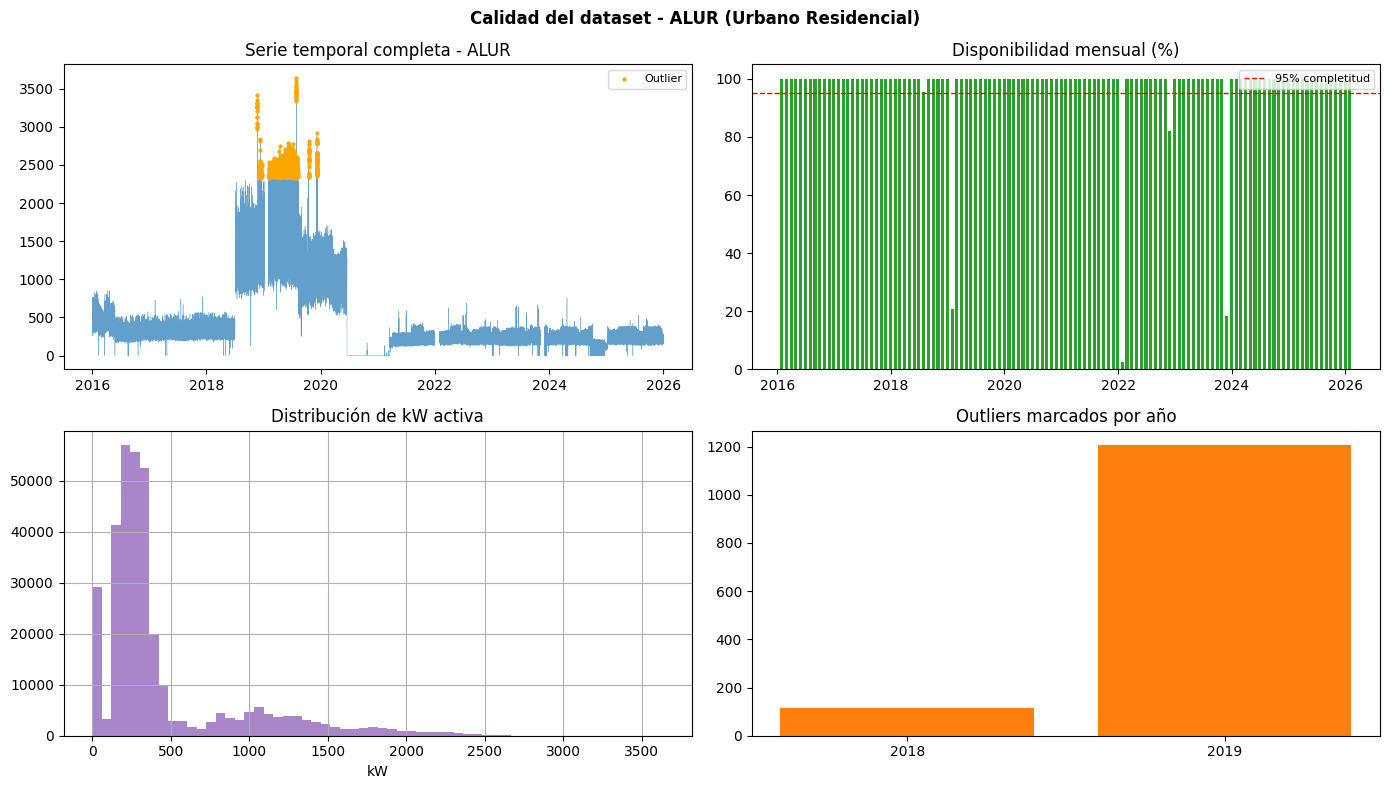


**Conclusión — ALUR (Urbano Residencial):**
  - Completitud: 97.64%  |  CV (std/media): 1.043  (este valor es el que calibra el umbral práctico de ALUR en la Parte I)
  - Los outliers se concentran en [2019, 2018], coincidiendo con [2019] — evidencia directa (no solo de ALRG) del régimen atípico 2019-2021 excluido del entrenamiento (fila 2, A.5).

ALRA (Rural Residencial-Agrícola) — Shape: (350688, 11)  |  Rango: 2016-01-01 00:15:00 a 2026-01-01 00:00:00


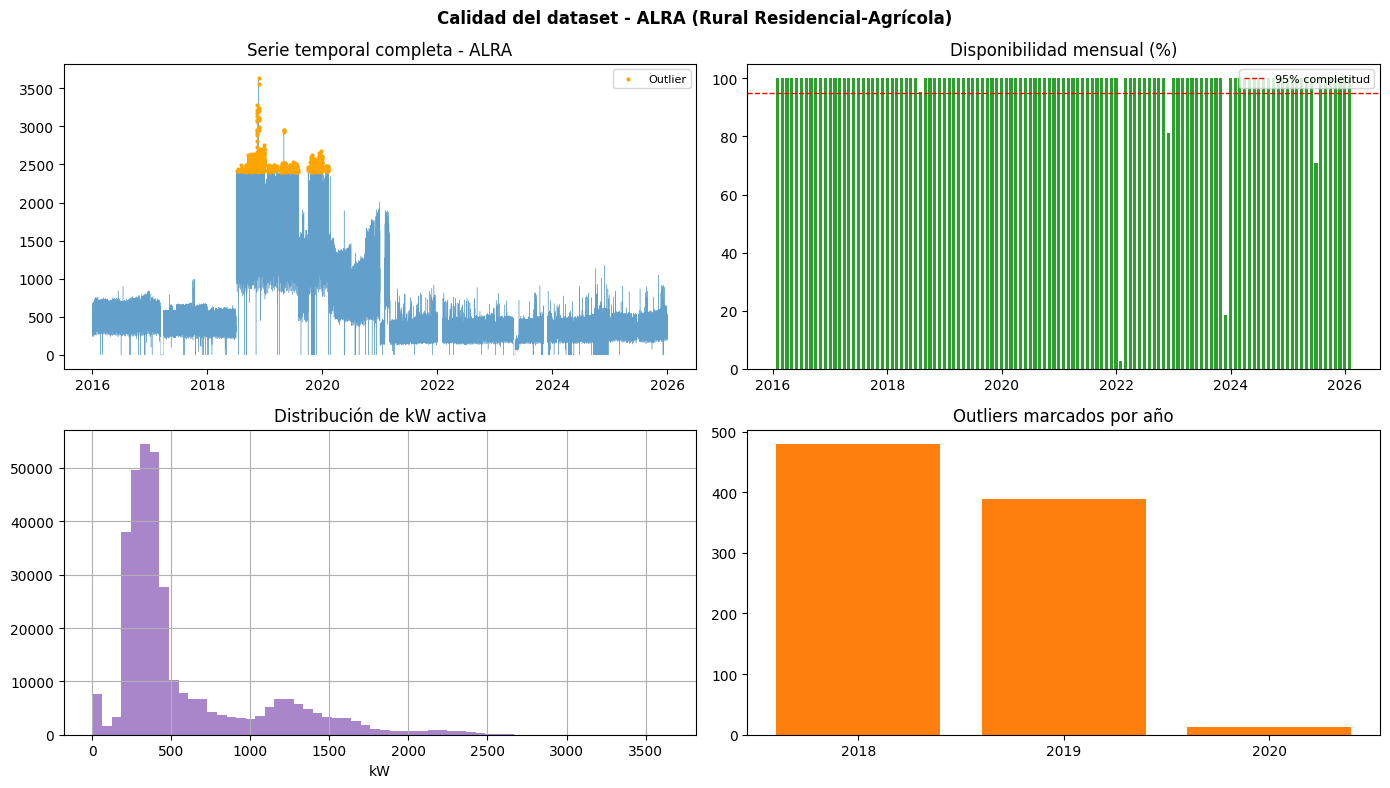


**Conclusión — ALRA (Rural Residencial-Agrícola):**
  - Completitud: 98.07%  |  CV (std/media): 0.812  (este valor es el que calibra el umbral práctico de ALRA en la Parte I)
  - Los outliers se concentran en [2018, 2019], coincidiendo con [2019] — evidencia directa (no solo de ALRG) del régimen atípico 2019-2021 excluido del entrenamiento (fila 2, A.5).

ALRG (Rural Residencial-Ganadero) — Shape: (350688, 11)  |  Rango: 2016-01-01 00:15:00 a 2026-01-01 00:00:00


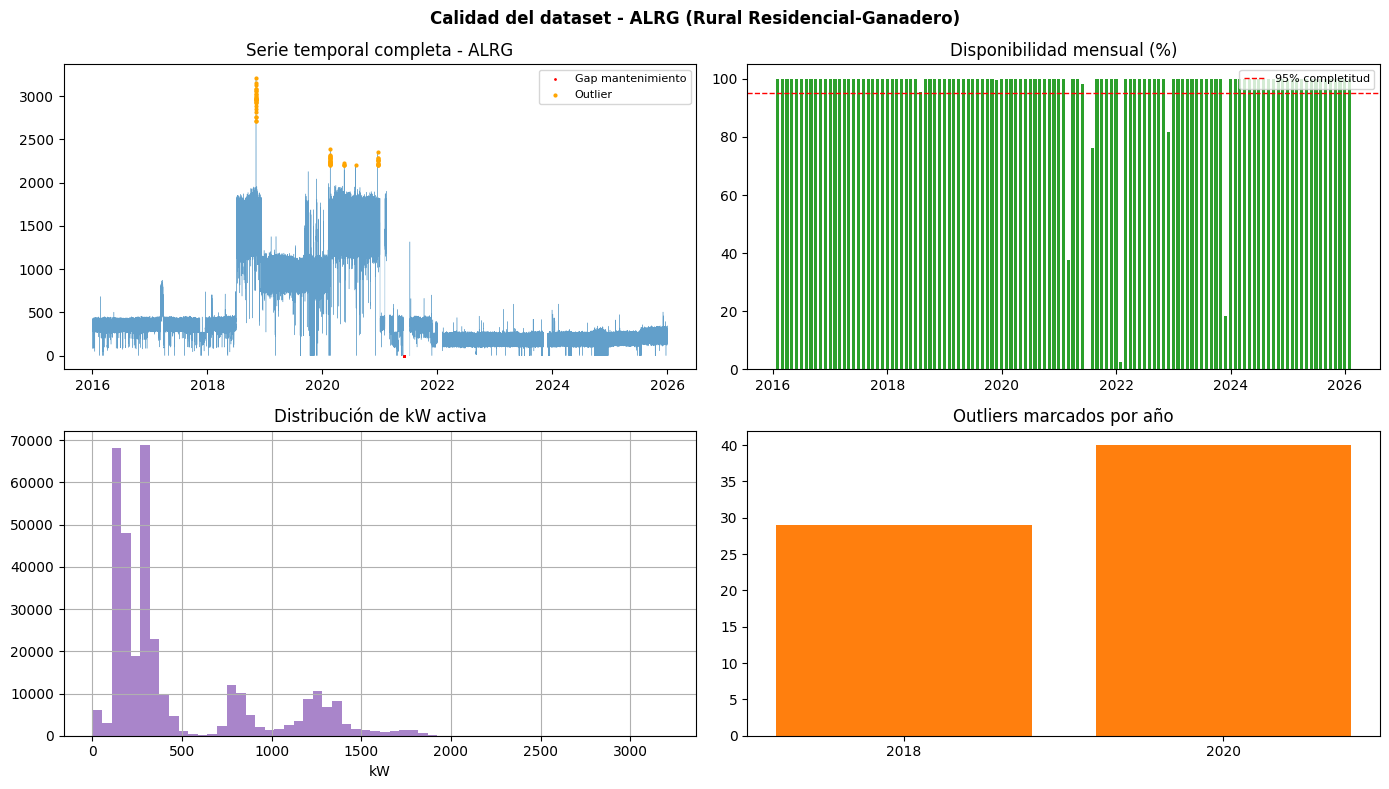


**Conclusión — ALRG (Rural Residencial-Ganadero):**
  - Completitud: 96.80%  |  CV (std/media): 0.933  (este valor es el que calibra el umbral práctico de ALRG en la Parte I)
  - Los outliers se concentran en [2020, 2018], coincidiendo con [2020] — evidencia directa (no solo de ALRG) del régimen atípico 2019-2021 excluido del entrenamiento (fila 2, A.5).



In [4]:
# ============================================================
# A.3 — Calidad de datos, los 5 alimentadores (antes solo se graficaba
# ALRG como "ejemplo"). Cada figura usa el mismo layout 2x2: serie
# completa, disponibilidad mensual, distribución de kW y outliers por
# año. Después de cada figura se imprime una conclusión que conecta la
# observación (CV, outliers concentrados en cierto período, etc.) con
# la fila correspondiente de la tabla A.5 — para que A.5 quede
# justificada con evidencia de cada alimentador, no solo enunciada.
# ============================================================

def graficar_calidad_alimentador(codigo, descripcion):
    df = pd.read_csv(RUTA_DATASET / f'dataset_limpio_{codigo}.csv', index_col=0, parse_dates=True)
    print(f'{codigo} ({descripcion}) — Shape: {df.shape}  |  Rango: {df.index.min()} a {df.index.max()}')

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    ax = axes[0, 0]
    ax.plot(df.index, df['kw_activa'], lw=0.3, color=C['azul'], alpha=0.7)
    if 'es_gap_mantenimiento' in df.columns:
        gaps = df[df['es_gap_mantenimiento'] == True]
        if len(gaps): ax.scatter(gaps.index, [0]*len(gaps), color='red', s=1, label='Gap mantenimiento')
    if 'es_outlier' in df.columns:
        outliers = df[df['es_outlier'] == True]
        if len(outliers): ax.scatter(outliers.index, outliers['kw_activa'], color='orange', s=4, label='Outlier', zorder=5)
    ax.set_title(f'Serie temporal completa - {codigo}'); ax.legend(fontsize=8)

    ax = axes[0, 1]
    disponibilidad = df['kw_activa'].notna().resample('ME').mean() * 100
    ax.bar(disponibilidad.index, disponibilidad.values, width=20, color=C['verde'])
    ax.axhline(95, color='red', ls='--', lw=1, label='95% completitud')
    ax.set_title('Disponibilidad mensual (%)'); ax.legend(fontsize=8)

    ax = axes[1, 0]
    df['kw_activa'].dropna().hist(bins=60, ax=ax, color=C['morado'], alpha=0.8)
    ax.set_title('Distribución de kW activa'); ax.set_xlabel('kW')

    outliers_por_anio = pd.Series(dtype=int)
    ax = axes[1, 1]
    if 'es_outlier' in df.columns:
        mask_out = df['es_outlier'] == True
        if mask_out.any():
            outliers_por_anio = df[mask_out].groupby(df[mask_out].index.year).size()
            ax.bar(outliers_por_anio.index.astype(str), outliers_por_anio.values, color=C['naranja'])
    ax.set_title('Outliers marcados por año')

    plt.suptitle(f'Calidad del dataset - {codigo} ({descripcion})', fontweight='bold')
    plt.tight_layout(); plt.show()

    return df, outliers_por_anio


for ali in ALIMENTADORES:
    codigo, descripcion = ali['codigo'], ali['descripcion']
    df_ali, outliers_anio = graficar_calidad_alimentador(codigo, descripcion)

    completitud = df_ali['kw_activa'].notna().mean() * 100
    cv_real = df_ali['kw_activa'].std() / df_ali['kw_activa'].mean()
    anios_pico = outliers_anio.sort_values(ascending=False).head(2).index.tolist() if len(outliers_anio) else []
    anios_atipicos = [a for a in anios_pico if a in (2019, 2020, 2021)]

    print(f'\n**Conclusión — {codigo} ({descripcion}):**')
    print(f'  - Completitud: {completitud:.2f}%  |  CV (std/media): {cv_real:.3f}  '
          f'(este valor es el que calibra el umbral práctico de {codigo} en la Parte I)')
    if anios_pico:
        if anios_atipicos:
            print(f'  - Los outliers se concentran en {anios_pico}, coincidiendo con {anios_atipicos} — '
                  f'evidencia directa (no solo de ALRG) del régimen atípico 2019-2021 excluido del entrenamiento (fila 2, A.5).')
        else:
            print(f'  - Los outliers se concentran en {anios_pico}, sin coincidir fuertemente con 2019-2021 en este alimentador.')

    print()




### Hallazgos por alimentador

*(Ordenados de mayor a menor CV)*

### ALUR — Urbano Residencial (CV = 1.043, el más alto de los 5)
- Completitud 97.64% — la segunda más baja de los 5.
- 8,501 huecos de comunicación — el segundo valor más alto.
- 1,319 outliers marcados — el segundo más alto (después de ALIN).
- kW std (470.75) **supera** a la kW media (451.43).
- **Hallazgo:** es llamativo que el alimentador "solo residencial" tenga el CV más alto de los 5 —
  incluso por encima del industrial. Dado que también acumula el segundo mayor número de huecos y
  de outliers, parte de esa dispersión medida podría estar inflada por calidad de datos (huecos
  interpolados, outliers no del todo depurados) y no solo por el comportamiento real de la carga.
  Vale la pena mencionarlo como una limitación a considerar en la interpretación del resultado, no
  solo como un dato de la tabla.

### ALIN — Industrial (CV = 1.039, el segundo más alto)
- Completitud 99.04% — la más alta de los 5 (mejor calidad de comunicación SCADA).
- Solo 7 huecos grandes sin imputar — la mayoría de sus 3,436 huecos fueron chicos e
  interpolables.
- 3,503 outliers marcados — **por mucho** el valor más alto de los 5 (2.7× el segundo lugar, ALUR
  con 1,319).
- kW media (163.11) la más baja de los 5, pero kW std (169.50) la supera.
- **Hallazgo:** a diferencia de ALUR, en ALIN la alta dispersión sí tiene una explicación operativa
  clara: es consistente con una demanda industrial dominada por procesos intermitentes (arranques
  de motores, cargas puntuales de maquinaria) que no siguen un patrón horario/calendario tan
  regular como el residencial o comercial. La combinación de completitud alta + outliers altísimos
  sugiere que el medidor está capturando bien la señal, y que la volatilidad es real, no un artefacto
  de datos faltantes.

### ALRG — Rural Residencial-Ganadero (CV = 0.933, moderado)
- Completitud 96.80% — la **más baja** de los 5.
- 11,243 huecos de comunicación y 9 huecos grandes sin imputar — ambos el valor **más alto** de
  los 5, por un margen amplio.
- Solo 69 outliers marcados — el valor **más bajo** de los 5.
- **Hallazgo:** es el alimentador con más problemas de telemetría (más huecos, más huecos grandes),  por esta razon se eligió para hacer las pruebas contempladas en la parte B, por el contraste es el que menos picos atípicos de demanda muestra. Es consistente con una actividad ganadera que genera una carga rutinaria y predecible (ordeño, iluminación en horarios fijos) — el reto de calidad aquí no es la volatilidad de la demanda sino la
  cobertura de comunicación, algo a documentar como limitación de infraestructura de medición, debido a modificaciones y mantenimientos que ha sufrido este alimentador, más que del comportamiento de carga que posee este alimentador.

### ALUC — Urbano Residencial-Comercial (CV = 0.884, el segundo más bajo)
- Completitud 98.69%.
- Solo 5 huecos grandes sin imputar — el valor más bajo de los 5.
- 161 outliers marcados — el segundo valor más bajo.
- kW media (484.21) la segunda más alta de los 5.
- **Hallazgo:** es el alimentador con el perfil de datos más "limpio" en conjunto (pocos huecos
  grandes, pocos outliers), consistente con una mezcla residencial-comercial urbana con rutinas
  horarias y semanales bien marcadas (comercios con horario fijo, patrones residenciales
  regulares). Aun así su CV (0.884) ya está por encima de lo que se asumiría para una categoría
  "urbana" bajo el umbral teórico de 5%.

### ALRA — Rural Residencial-Agrícola (CV = 0.812, el más bajo de los 5)
- Completitud 98.07%.
- kW media (565.87) — la **más alta** de los 5 (para "rural" es alto, pero consistente con
  cargas agrícolas de bombeo/riego con demanda base considerable).
- 879 outliers marcados — moderado.
- **Hallazgo:** es el alimentador con la demanda proporcionalmente más estable de los 5, a pesar de
  tener el mayor consumo promedio. Es razonable a que buena parte de la carga agrícola
  (riego, bombeo) sigue horarios programados y recurrentes, más que a variabilidad espontánea del
  consumo — de ahí que se mantenga en el umbral rural base (8%) sin necesidad de ajuste.

### A.4 — Reconstrucción de Features (usada en todas las Partes siguientes)

In [5]:
# ============================================================
# A.4 — construir_features(): 26 features de ingeniería
#
# ANTI-FUGA: todo estadístico móvil usa shift(1) ANTES del rolling — la
# ventana de 96 pasos para kw_media_24h, kw_std_24h, etc. SIEMPRE termina
# un paso antes del presente, nunca incluye la observación actual ni
# futura. Los lags (kw_lag_4...kw_lag_672) son, por construcción,
# referencias a pasos estrictamente anteriores. Los scalers (Partes B/C)
# se ajustan EXCLUSIVAMENTE sobre el set de entrenamiento.
# ============================================================

def construir_features(df_limpio):
    df = df_limpio.copy()
    idx = df.index
    paso_en_dia = idx.hour * 4 + idx.minute // 15
    df['paso_dia_sin'] = np.sin(2 * np.pi * paso_en_dia / 96)
    df['paso_dia_cos'] = np.cos(2 * np.pi * paso_en_dia / 96)
    df['dow_sin']  = np.sin(2 * np.pi * idx.dayofweek / 7)
    df['dow_cos']  = np.cos(2 * np.pi * idx.dayofweek / 7)
    df['mes_sin']  = np.sin(2 * np.pi * idx.month / 12)
    df['mes_cos']  = np.cos(2 * np.pi * idx.month / 12)
    semanas = idx.isocalendar().week.values
    df['semana_sin'] = np.sin(2 * np.pi * semanas / 52)
    df['semana_cos'] = np.cos(2 * np.pi * semanas / 52)
    df['es_fin_semana'] = (idx.dayofweek >= 5).astype(int)
    df['es_lunes']      = (idx.dayofweek == 0).astype(int)
    df['es_viernes']    = (idx.dayofweek == 4).astype(int)
    anios = range(idx.min().year, idx.max().year + 1)
    feriados_ec = holidays.Ecuador(years=list(anios))
    df['es_feriado_ec'] = idx.normalize().map(lambda d: 1 if d.date() in feriados_ec else 0).astype(int)
    df['flag_gap'] = df['es_gap_mantenimiento'].astype(int)
    kw = df['kw_activa'].copy()
    kw.loc[df['es_gap_mantenimiento']] = np.nan
    df['kw_lag_4']   = kw.shift(4)
    df['kw_lag_8']   = kw.shift(8)
    df['kw_lag_96']  = kw.shift(96)
    df['kw_lag_192'] = kw.shift(192)
    df['kw_lag_672'] = kw.shift(672)
    df['kw_media_24h'] = kw.shift(1).rolling(96, min_periods=24).mean()
    df['kw_std_24h']   = kw.shift(1).rolling(96, min_periods=24).std()
    df['kw_max_24h']   = kw.shift(1).rolling(96, min_periods=24).max()
    df['kw_min_24h']   = kw.shift(1).rolling(96, min_periods=24).min()
    df['kw_rango_24h'] = df['kw_max_24h'] - df['kw_min_24h']
    return df, LISTA_FEATURES


def detectar_ventanas_racionamiento(df_features, umbral_kw=30.0, min_duracion_pasos=4):
    kw = df_features['kw_activa'].fillna(0)
    es_bajo = kw < umbral_kw
    grupos = (es_bajo != es_bajo.shift()).cumsum()
    tamanos = es_bajo.groupby(grupos).transform('sum')
    return (es_bajo & (tamanos >= min_duracion_pasos)).values


def calcular_metricas(y_real, y_pred, nombre='Modelo', umbral_min=30.0):
    mascara = (y_real > umbral_min) & np.isfinite(y_real) & np.isfinite(y_pred)
    if mascara.sum() < 10:
        return {'modelo': nombre, 'mape': np.nan, 'rmse': np.nan, 'mae': np.nan, 'r2': np.nan}
    mape = np.mean(np.abs((y_real[mascara] - y_pred[mascara]) / y_real[mascara])) * 100
    rmse = np.sqrt(mean_squared_error(y_real.flatten(), y_pred.flatten()))
    mae  = mean_absolute_error(y_real.flatten(), y_pred.flatten())
    corr = np.corrcoef(y_real.flatten(), y_pred.flatten())[0, 1]
    return {'modelo': nombre, 'mape': round(float(mape), 3), 'rmse': round(float(rmse), 3),
            'mae': round(float(mae), 3), 'r2': round(float(corr**2), 4)}

print('✅ construir_features(), detectar_ventanas_racionamiento(), calcular_metricas() definidas')


# ============================================================
# Test ALINEADO: construye el test de régimen limpio (2024, sin
# racionamiento) usando un scaler YA AJUSTADO (por ejemplo, el de v1)
# en vez de ajustar uno nuevo — así cualquier modelo ya entrenado se
# puede evaluar sobre el MISMO período real que el modelo final, sin
# importar con qué split se entrenó originalmente. Esto es lo que
# permite comparar v1 y el modelo final de forma justa y graficarlos
# uno junto al otro (antes se graficaban con "real" de dos test sets
# distintos, lo cual producía gráficas desalineadas o en otra escala).
# ============================================================

def preparar_test_alineado(df_features, lista_features, ventana, horizonte, sc_X, sc_y,
                            umbral_racionamiento=30.0, paso=1):
    df = df_features[lista_features + ['es_gap_mantenimiento']].copy()
    for col in lista_features: df[col] = df[col].fillna(0)
    idx = df.index
    mask_test = idx.year == 2024
    df_test = df[mask_test]

    es_racionamiento = detectar_ventanas_racionamiento(df_features, umbral_racionamiento)
    gap_ts = df_test['es_gap_mantenimiento'].values
    gap_ts_limpio = gap_ts | es_racionamiento[mask_test]

    X_ts_sc = sc_X.transform(df_test[lista_features].values)  # scaler YA AJUSTADO (no .fit)
    y_ts_sc = sc_y.transform(df_test[['kw_activa']].values)

    X_out, y_out = [], []
    for i in range(ventana, len(X_ts_sc) - horizonte + 1, paso):
        if gap_ts_limpio[i-ventana:i].any() or gap_ts_limpio[i:i+horizonte].any(): continue
        X_out.append(X_ts_sc[i-ventana:i, :]); y_out.append(y_ts_sc[i:i+horizonte, 0])
    return np.array(X_out, dtype=np.float32), np.array(y_out, dtype=np.float32)

print('✅ preparar_test_alineado() definida — evalúa un modelo ya entrenado sobre el mismo período (2024, sin racionamiento)')


✅ construir_features(), detectar_ventanas_racionamiento(), calcular_metricas() definidas
✅ preparar_test_alineado() definida — evalúa un modelo ya entrenado sobre el mismo período (2024, sin racionamiento)


### A.5 — Hallazgos del Dataset que Motivaron Cada Decisión de Diseño

**v1 es el punto de partida** — la arquitectura y el split de referencia contra los que se mide,
después, el efecto real de cada corrección. A partir de v2, cada versión del modelo (Parte B) no
fue un cambio arbitrario — respondió a un hallazgo concreto encontrado al examinar los datos o los
resultados de la versión anterior:

| Hallazgo en los datos / resultados | Decisión de diseño | Versión que lo incorpora |
|---|---|---|
| **(Punto de partida)** — antes de cualquier diagnóstico sobre el dataset, se necesitaba una arquitectura y un split de referencia para poder medir, después, el efecto real de cada corrección | **Línea base**: LSTM simple (Conv1D + 3 capas LSTM apiladas), split porcentual 80/10/10 (sin excluir años ni filtrar racionamiento), target = kW absoluto, pérdida Huber asimétrica | v1 |
| Un split porcentual (80/10/10) sobre la serie cronológica puede dejar el test en un período con un régimen de demanda distinto al de entrenamiento, sin que el split lo evite explícitamente | Usar un split por **fechas explícitas**, no por porcentaje | v2 |
| Al inspeccionar 2019-2021 se encontró un régimen de demanda muy distinto al actual (parón por pandemia seguido de una activación industrial atípica en algunos alimentadores) — confirmado en los 5 alimentadores en la Parte A.3, no solo en el ejemplo original | **Excluir 2019-2021** del entrenamiento; años 2016-2018 + 2022 en adelante | v3 |
| En 2024 se identificaron cortes de energía programados (racionamiento nacional) — ventanas con kW sostenido cerca de cero que no reflejan un fallo del modelo sino un evento externo | Evaluar el modelo en dos condiciones: **test limpio** (sin racionamiento) y **test completo** (con racionamiento), para no ocultar ni sobre-penalizar este efecto | v3 en adelante |
| Con el régimen ya corregido, la persistencia (naive) superaba al LSTM entrenado sobre kW absolutos — el modelo no estaba aprendiendo estructura real, solo memorizando el nivel general | Reformular el target como **residuo** (Δ = y_real − persistencia), no kW absolutos | v4 |
| El CV (coeficiente de variación) difiere sustancialmente entre alimentadores (0.81 a 1.04, Parte A.3) — un único umbral urbano/rural no refleja esa diferencia | Calibrar el **umbral de aceptación por alimentador**, usando el CV como criterio | Umbrales prácticos (Parte I) |


## PARTE B — Desarrollo Metodológico v1→v2→v3→v4, Nativo a 1h (Solo ALRG)

Las 4 versiones se entrenan y evalúan **a horizonte=4 pasos (1 hora)**, ventana=96
pasos (24h de historial). El desarrollo se documenta sobre un solo alimentador (ALRG) debido a que es el alimentador con más problemas de telemetría (más huecos, más huecos grandes) y cada
versión responde a un hallazgo diagnóstico (Parte A.5), no a una arquitectura que deba probarse
por separado en cada alimentador — ese conocimiento ya incorporado se aplica directamente en la
Parte C para los otros 4.


### B.1 — Pérdidas y Arquitecturas (v1 a v4)

**Arquitecturas V1 → V4**

Las 4 versiones comparten la misma arquitectura (Conv1D causal → pila de LSTM → capa(s) densa(s) →
salida), pero **cada una cambia capas, unidades, regularización y hasta la función de activación
de salida** — no es la misma red con ajustes cosméticos. A continuación el detalle exacto, versión
por versión mediante una tabla comparativa.


**Tabla comparativa**

| | V1 | V2 | V3 | V4 |
|---|---|---|---|---|
| Conv1D | 32 filtros, sin reg. | 32 filtros, L2 | 32 filtros, L2 | **16 filtros**, L2 |
| LSTM (capas → unidades) | 3 → 128,64,32 | **2** → 128,64 | 2 → 128,64 | 2 → **64,32** |
| Normalización | ninguna | LayerNorm + BatchNorm | LayerNorm + BatchNorm | LayerNorm + BatchNorm |
| Dropout | ninguno | 0.15 / 0.15 / 0.10 | 0.15 / 0.15 / 0.10 | **0.20 / 0.20 / 0.15** |
| Regularización densas | — | L2 | L2 | **L1+L2** |
| Rama de persistencia (`Lambda`) | no | no | **sí** | no (target ya es residuo) |
| Activación salida | relu | relu | relu | **linear** (obligatorio para residuo negativo) |
| Pérdida | Huber asimétrica (δ=1.0) | Huber asimétrica (δ=1.0) | Huber asimétrica (δ=1.0) | **Huber simétrica (δ=0.5)** |
| Learning rate | 1e-3 | 5e-4 | 3e-4 | 2e-4 |
| Target | kW absoluto | kW absoluto | kW absoluto | **residuo (Δ)** |
| Justificación | Arquitectura razonable por defecto,sin ningún mecanismo que controle sobreajuste (referencia para medir cuánto aporta cada versión posterior). | Split por fechas, ese cambio expone al modelo a un régimen de test más difícil, se acompañó de regularización más fuerte para intentar compensar. | Arquitectura de dos ramas. Una capa Lambda extrae directamente los últimos valores observados de kW de la entrada cruda (sin pasar por el LSTM) y los convierte en una señal explícita que se concatena con lo que aprende la rama LSTM, motivado por el hallazgo de que la persistencia pura superaba al LSTM entrenado sobre kW absolutos | Arquitectura más compacta: menos filtros Conv1D, menos unidades LSTM, pero más regularización (L2 en todo, L1+L2 en las densas, Dropout subido a 0.20). Es una arquitectura deliberadamente más chica y más regularizada — menos capacidad bruta, pero con menos grados de libertad para sobreajustar |

**El cambio de pérdida asimétrica → simétrica en V4.** V1-V3 penalizan la subestimación 1.5× más (razonable para kW absoluto: no anticipar demanda es más costoso para EEASA que sobreestimarla). V4 cambia a una pérdida simétrica, porque para un *residuo* ya no aplica la misma lógica de riesgo asimétrico.

**v4 ya no tiene la rama dual de v3** — se quita por completo la rama de persistencia con Lambda, porque ahora la persistencia se resta antes de entrenar (el target ya es el residuo), no hace falta dársela al modelo como input aparte.

**La capa densa oculta usa tanh en vez de relu** — conviene evitar apagar unidades para señales negativas tan cerca de la salida.

**La salida final usa activation='linear', no relu como v1-v3** El residuo (Δ = y_real − persistencia) puede ser negativo (cuando la persistencia sobreestima) o positivo. Si la salida usara relu como en las versiones anteriores, el modelo no podría predecir residuos negativos nunca — quedaría matemáticamente incapacitado para corregir a la baja


In [6]:
# ============================================================
# B.1 — Funciones de pérdida y las 4 arquitecturas
# ============================================================

def huber_asimetrico_v1(delta=1.0, penalizacion_bajo=1.5):
    """Penaliza 50% más las subestimaciones (más costoso para EEASA no anticipar demanda)."""
    def loss(y_true, y_pred):
        error = y_true - y_pred
        abs_e = tf.abs(error)
        huber = tf.where(abs_e <= delta, 0.5*tf.square(error), delta*(abs_e-0.5*delta))
        return tf.reduce_mean(tf.where(error > 0, huber * penalizacion_bajo, huber))
    loss.__name__ = 'huber_asimetrico'
    return loss


def huber_simetrico(delta=0.5):
    def loss(y_true, y_pred):
        e = y_true - y_pred
        return tf.reduce_mean(tf.where(tf.abs(e) <= delta, 0.5*tf.square(e), delta*(tf.abs(e)-0.5*delta)))
    loss.__name__ = 'huber_simetrico_residuos'
    return loss


def construir_modelo_v1(n_features, ventana, horizonte, lr=1e-3):
    """Línea base — sin LayerNorm (v2 lo agrega como mejora), sin residuos."""
    entradas = Input(shape=(ventana, n_features), name='entrada')
    x = Conv1D(32, kernel_size=3, padding='causal', activation='relu')(entradas)
    x = LSTM(128, return_sequences=True, name='lstm_1')(x)
    x = LSTM(64, return_sequences=True, name='lstm_2')(x)
    x = LSTM(32, return_sequences=False, name='lstm_3')(x)
    salidas = Dense(horizonte, activation='relu', name='salida')(x)
    modelo = Model(inputs=entradas, outputs=salidas, name='LSTM_v1_LineaBase')
    modelo.compile(optimizer=Adam(learning_rate=lr, clipnorm=1.0), loss=huber_asimetrico_v1(), metrics=['mae'])
    return modelo


def construir_modelo_v2(n_features, ventana, horizonte, lr=5e-4):
    """Agrega LayerNormalization + split por fechas (ver preparar_datos_corregido)."""
    entradas = Input(shape=(ventana, n_features), name='entrada')
    x = LayerNormalization(name='layer_norm_entrada')(entradas)
    x = Conv1D(32, kernel_size=3, padding='causal', activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = LSTM(128, return_sequences=True, kernel_regularizer=l2(1e-4), recurrent_regularizer=l2(1e-5), name='lstm_1')(x)
    x = BatchNormalization()(x); x = Dropout(0.15)(x)
    x = LSTM(64, return_sequences=False, kernel_regularizer=l2(1e-4), name='lstm_2')(x)
    x = BatchNormalization()(x); x = Dropout(0.15)(x)
    x = Dense(192, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = Dropout(0.10)(x)
    salidas = Dense(horizonte, activation='relu', name='salida')(x)
    modelo = Model(inputs=entradas, outputs=salidas, name='LSTM_v2')
    modelo.compile(optimizer=Adam(learning_rate=lr, clipnorm=1.0), loss=huber_asimetrico_v1(), metrics=['mae'])
    return modelo


def construir_modelo_v3(n_features, ventana, horizonte, lr=3e-4):
    """Dual-input: rama LSTM + rama de persistencia directa (últimos `horizonte` pasos)."""
    entradas = Input(shape=(ventana, n_features), name='entrada')
    x = LayerNormalization(name='ln')(entradas)
    x = Conv1D(32, kernel_size=3, padding='causal', activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = LSTM(128, return_sequences=True, kernel_regularizer=l2(1e-4), name='lstm_1')(x)
    x = BatchNormalization()(x); x = Dropout(0.15)(x)
    x = LSTM(64, return_sequences=False, kernel_regularizer=l2(1e-4), name='lstm_2')(x)
    x = BatchNormalization()(x); x = Dropout(0.15)(x)
    rama_lstm = Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(x)

    ultimos_kw  = Lambda(lambda t: t[:, -horizonte:, 0:1], name='persistencia_directa')(entradas)
    ultimos_vec = Flatten(name='flatten_persistencia')(ultimos_kw)
    rama_persist = Dense(max(horizonte, 8), activation='relu', kernel_regularizer=l2(1e-4))(ultimos_vec)

    fusionado = Concatenate(name='fusion')([rama_lstm, rama_persist])
    z = Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(fusionado)
    z = Dropout(0.10)(z)
    salidas = Dense(horizonte, activation='relu', name='salida')(z)
    modelo = Model(inputs=entradas, outputs=salidas, name='LSTM_v3_DualInput')
    modelo.compile(optimizer=Adam(learning_rate=lr, clipnorm=1.0), loss=huber_asimetrico_v1(), metrics=['mae'])
    return modelo


def construir_modelo_v4(n_features, ventana, horizonte, lr=2e-4,
                         l2_conv=1e-4, l2_lstm=1e-4, l1l2_dense=(1e-5, 1e-4)):
    """Aprendizaje de residuos — arquitectura compacta y regularizada."""
    entradas = Input(shape=(ventana, n_features), name='entrada')
    x = LayerNormalization(name='ln')(entradas)
    x = Conv1D(16, kernel_size=3, padding='causal', activation='relu', kernel_regularizer=l2(l2_conv))(x)
    x = LSTM(64, return_sequences=True, kernel_regularizer=l2(l2_lstm), recurrent_regularizer=l2(l2_lstm/10), name='lstm_1')(x)
    x = BatchNormalization()(x); x = Dropout(0.20)(x)
    x = LSTM(32, return_sequences=False, kernel_regularizer=l2(l2_lstm), name='lstm_2')(x)
    x = BatchNormalization()(x); x = Dropout(0.20)(x)
    x = Dense(128, activation='tanh', kernel_regularizer=l1_l2(l1=l1l2_dense[0], l2=l1l2_dense[1]))(x)
    x = Dropout(0.15)(x)
    salidas = Dense(horizonte, activation='linear', kernel_regularizer=l1_l2(l1=l1l2_dense[0], l2=l1l2_dense[1]), name='delta_pred')(x)
    modelo = Model(inputs=entradas, outputs=salidas, name='LSTM_v4_Residual')
    modelo.compile(optimizer=Adam(learning_rate=lr, clipnorm=1.0), loss=huber_simetrico(delta=0.5), metrics=['mae'])
    return modelo

print('✅ 4 arquitecturas (v1-v4) y 2 funciones de pérdida definidas — todas parametrizadas por horizonte')


✅ 4 arquitecturas (v1-v4) y 2 funciones de pérdida definidas — todas parametrizadas por horizonte


### B.2 — Preparación de Datos por Versión (v1: split porcentual, v2: split por fechas, v3/v4: régimen limpio)

In [7]:
# ============================================================
# B.2 — Funciones de preparación de datos, nativas a horizonte=4
# ============================================================

def preparar_datos_v1_percentual(df_features, lista_features, ventana, horizonte, paso=1):
    """v1 — split porcentual 80/10/10 (sin excluir ningún año, sin filtrar racionamiento)."""
    df = df_features[lista_features + ['es_gap_mantenimiento']].copy()
    for col in lista_features: df[col] = df[col].fillna(0)
    n = len(df)
    i_train, i_val = int(n*0.8), int(n*0.9)
    df_train, df_val, df_test = df.iloc[:i_train], df.iloc[i_train:i_val], df.iloc[i_val:]

    sc_X, sc_y = MinMaxScaler(), MinMaxScaler()
    X_tr_sc = sc_X.fit_transform(df_train[lista_features].values)
    X_vl_sc = sc_X.transform(df_val[lista_features].values)
    X_ts_sc = sc_X.transform(df_test[lista_features].values)
    y_tr_sc = sc_y.fit_transform(df_train[['kw_activa']].values)
    y_vl_sc = sc_y.transform(df_val[['kw_activa']].values)
    y_ts_sc = sc_y.transform(df_test[['kw_activa']].values)
    gap_tr, gap_vl, gap_ts = (df_train['es_gap_mantenimiento'].values,
                               df_val['es_gap_mantenimiento'].values, df_test['es_gap_mantenimiento'].values)

    def crear_ventanas(X_sc, y_sc, gap_mask):
        X_out, y_out = [], []
        for i in range(ventana, len(X_sc) - horizonte + 1, paso):
            if gap_mask[i-ventana:i].any() or gap_mask[i:i+horizonte].any(): continue
            X_out.append(X_sc[i-ventana:i, :]); y_out.append(y_sc[i:i+horizonte, 0])
        return np.array(X_out, dtype=np.float32), np.array(y_out, dtype=np.float32)

    X_train, y_train = crear_ventanas(X_tr_sc, y_tr_sc, gap_tr)
    X_val,   y_val   = crear_ventanas(X_vl_sc, y_vl_sc, gap_vl)
    X_test,  y_test  = crear_ventanas(X_ts_sc, y_ts_sc, gap_ts)
    return {'X_train': X_train, 'y_train': y_train, 'X_val': X_val, 'y_val': y_val,
            'X_test': X_test, 'y_test': y_test, 'sc_X': sc_X, 'sc_y': sc_y,
            'n_features': len(lista_features), 'ventana': ventana, 'horizonte': horizonte}


def preparar_datos_corregido(df_features, lista_features, ventana, horizonte,
                              fecha_corte_train='2022-12-31', fecha_corte_val='2023-12-31', paso=1):
    """v2 — división por fechas absolutas (SIN excluir 2019-2021 todavía)."""
    df = df_features[lista_features + ['es_gap_mantenimiento']].copy()
    for col in lista_features: df[col] = df[col].fillna(0)
    mask_train = df.index <= fecha_corte_train
    mask_val   = (df.index > fecha_corte_train) & (df.index <= fecha_corte_val)
    mask_test  = df.index > fecha_corte_val
    df_train, df_val, df_test = df[mask_train], df[mask_val], df[mask_test]

    sc_X, sc_y = MinMaxScaler(), MinMaxScaler()
    X_tr_sc = sc_X.fit_transform(df_train[lista_features].values)
    X_vl_sc = sc_X.transform(df_val[lista_features].values)
    X_ts_sc = sc_X.transform(df_test[lista_features].values)
    y_tr_sc = sc_y.fit_transform(df_train[['kw_activa']].values)
    y_vl_sc = sc_y.transform(df_val[['kw_activa']].values)
    y_ts_sc = sc_y.transform(df_test[['kw_activa']].values)
    gap_tr, gap_vl, gap_ts = (df_train['es_gap_mantenimiento'].values,
                               df_val['es_gap_mantenimiento'].values, df_test['es_gap_mantenimiento'].values)

    def crear_ventanas(X_sc, y_sc, gap_mask):
        X_out, y_out = [], []
        for i in range(ventana, len(X_sc) - horizonte + 1, paso):
            if gap_mask[i-ventana:i].any() or gap_mask[i:i+horizonte].any(): continue
            X_out.append(X_sc[i-ventana:i, :]); y_out.append(y_sc[i:i+horizonte, 0])
        return np.array(X_out, dtype=np.float32), np.array(y_out, dtype=np.float32)

    X_train, y_train = crear_ventanas(X_tr_sc, y_tr_sc, gap_tr)
    X_val,   y_val   = crear_ventanas(X_vl_sc, y_vl_sc, gap_vl)
    X_test,  y_test  = crear_ventanas(X_ts_sc, y_ts_sc, gap_ts)
    return {'X_train': X_train, 'y_train': y_train, 'X_val': X_val, 'y_val': y_val,
            'X_test': X_test, 'y_test': y_test, 'sc_X': sc_X, 'sc_y': sc_y,
            'n_features': len(lista_features), 'ventana': ventana, 'horizonte': horizonte}


def preparar_datos_regimen_limpio(df_features, lista_features, ventana, horizonte,
                                   umbral_racionamiento=30.0, paso=1, anio_inicio_train=2016):
    """v3/v4 — régimen limpio: excluye 2019-2021 y racionamiento 2024 del test."""
    df = df_features[lista_features + ['es_gap_mantenimiento']].copy()
    for col in lista_features: df[col] = df[col].fillna(0)
    idx = df.index
    mask_train = (((idx.year >= anio_inicio_train) & (idx.year <= 2018)) | (idx.year == 2022) |
                  ((idx.year == 2023) & (idx.month <= 6)))
    mask_val  = (idx.year == 2023) & (idx.month >= 7)
    mask_test = idx.year == 2024
    df_train, df_val, df_test = df[mask_train], df[mask_val], df[mask_test]

    es_racionamiento = detectar_ventanas_racionamiento(df_features, umbral_racionamiento)

    sc_X, sc_y = MinMaxScaler(), MinMaxScaler()
    X_tr_sc = sc_X.fit_transform(df_train[lista_features].values)
    X_vl_sc = sc_X.transform(df_val[lista_features].values)
    X_ts_sc = sc_X.transform(df_test[lista_features].values)
    y_tr_sc = sc_y.fit_transform(df_train[['kw_activa']].values)
    y_vl_sc = sc_y.transform(df_val[['kw_activa']].values)
    y_ts_sc = sc_y.transform(df_test[['kw_activa']].values)

    gap_tr = df_train['es_gap_mantenimiento'].values
    gap_vl = df_val['es_gap_mantenimiento'].values
    gap_ts = df_test['es_gap_mantenimiento'].values
    gap_ts_limpio = gap_ts | es_racionamiento[mask_test]

    def crear_ventanas(X_sc, y_sc, gap_mask):
        X_out, y_out = [], []
        for i in range(ventana, len(X_sc) - horizonte + 1, paso):
            if gap_mask[i-ventana:i].any() or gap_mask[i:i+horizonte].any(): continue
            X_out.append(X_sc[i-ventana:i, :]); y_out.append(y_sc[i:i+horizonte, 0])
        return np.array(X_out, dtype=np.float32), np.array(y_out, dtype=np.float32)

    X_train, y_train = crear_ventanas(X_tr_sc, y_tr_sc, gap_tr)
    X_val,   y_val   = crear_ventanas(X_vl_sc, y_vl_sc, gap_vl)
    X_test_clean, y_test_clean = crear_ventanas(X_ts_sc, y_ts_sc, gap_ts_limpio)
    X_test_full,  y_test_full  = crear_ventanas(X_ts_sc, y_ts_sc, gap_ts)

    return {'X_train': X_train, 'y_train': y_train, 'X_val': X_val, 'y_val': y_val,
            'X_test_clean': X_test_clean, 'y_test_clean': y_test_clean,
            'X_test_full': X_test_full, 'y_test_full': y_test_full,
            'sc_X': sc_X, 'sc_y': sc_y, 'n_features': len(lista_features),
            'ventana': ventana, 'horizonte': horizonte}

print('✅ Funciones de preparación de datos definidas (v1, v2, v3/v4)')


✅ Funciones de preparación de datos definidas (v1, v2, v3/v4)


### B.3 — Entrenar v1 (ALRG, nativo a 1h)

In [8]:
df_limpio_alrg = pd.read_csv(RUTA_DATASET / 'dataset_limpio_ALRG.csv', index_col=0, parse_dates=True)
df_features_alrg, _ = construir_features(df_limpio_alrg)

tensores_v1 = preparar_datos_v1_percentual(df_features_alrg, LISTA_FEATURES, VENTANA_1H, HORIZONTE_1H, paso=1)
print(f"Tensores v1 — train: {len(tensores_v1['X_train']):,}  val: {len(tensores_v1['X_val']):,}  test: {len(tensores_v1['X_test']):,}")

ruta_v1 = RUTA_SALIDAS / 'lstm_v1_ALRG_nativo1h_best.keras'
_existente = buscar_archivo_real('lstm_v1_ALRG_nativo1h_best.keras')

if REENTRENAR_TODO or _existente is None:
    modelo_v1 = construir_modelo_v1(tensores_v1['n_features'], VENTANA_1H, HORIZONTE_1H)
    cb = [EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=0, min_delta=1e-5),
          ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-7, verbose=0),
          ModelCheckpoint(filepath=str(ruta_v1), monitor='val_loss', save_best_only=True, verbose=0)]
    print('Entrenando v1 (nativo 1h)...')
    hist = modelo_v1.fit(tensores_v1['X_train'], tensores_v1['y_train'],
                          validation_data=(tensores_v1['X_val'], tensores_v1['y_val']),
                          epochs=150, batch_size=128, callbacks=cb, shuffle=True, verbose=0)
    modelo_v1.load_weights(ruta_v1)
    print(f"OK v1: {len(hist.history['loss'])} epocas, mejor val_loss={min(hist.history['val_loss']):.6f}")
else:
    modelo_v1 = tf.keras.models.load_model(_existente, compile=False, safe_mode=False)
    print(f'✅ v1 (ALRG) cargado desde {_existente} — sin reentrenar')

# Métrica propia (su split porcentual) — referencia de desarrollo (Parte B.7)
y_pred_v1_propio = np.clip(tensores_v1['sc_y'].inverse_transform(
    modelo_v1.predict(tensores_v1['X_test'], batch_size=128, verbose=0)), 0, None)
y_real_v1_propio = tensores_v1['sc_y'].inverse_transform(tensores_v1['y_test'])
m_v1 = calcular_metricas(y_real_v1_propio, y_pred_v1_propio, 'v1 (nativo 1h, propio test)')
print(f"\nv1 (ALRG, test propio) — MAPE: {m_v1['mape']:.3f}%  R²: {m_v1['r2']:.4f}")

# Métrica y predicciones ALINEADAS (mismo test 2024 que el modelo final) — para Parte C/K
X_test_alineado_alrg, y_test_alineado_alrg = preparar_test_alineado(
    df_features_alrg, LISTA_FEATURES, VENTANA_1H, HORIZONTE_1H, tensores_v1['sc_X'], tensores_v1['sc_y'])
y_pred_v1 = np.clip(tensores_v1['sc_y'].inverse_transform(
    modelo_v1.predict(X_test_alineado_alrg, batch_size=128, verbose=0)), 0, None)
y_real_v1 = tensores_v1['sc_y'].inverse_transform(y_test_alineado_alrg)
m_v1_alineado = calcular_metricas(y_real_v1, y_pred_v1, 'v1 (nativo 1h, test alineado)')
print(f"v1 (ALRG, test alineado, mismo que modelo final) — MAPE: {m_v1_alineado['mape']:.3f}%  R²: {m_v1_alineado['r2']:.4f}")

del modelo_v1; tf.keras.backend.clear_session(); gc.collect()


Tensores v1 — train: 280,256  val: 34,970  test: 34,970


2026-08-15 01:19:54.502040: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


✅ v1 (ALRG) cargado desde /kaggle/input/datasets/dpou45/input-final-titulacion/lstm_v1_ALRG_nativo1h_best.keras — sin reentrenar

v1 (ALRG, test propio) — MAPE: 4.273%  R²: 0.9227
v1 (ALRG, test alineado, mismo que modelo final) — MAPE: 4.491%  R²: 0.9009


0

### B.4 — Entrenar v2 (ALRG, nativo a 1h — split por fechas + LayerNorm)

In [9]:
tensores_v2 = preparar_datos_corregido(df_features_alrg, LISTA_FEATURES, VENTANA_1H, HORIZONTE_1H, paso=1)
print(f"Tensores v2 — train: {len(tensores_v2['X_train']):,}  val: {len(tensores_v2['X_val']):,}  test: {len(tensores_v2['X_test']):,}")

ruta_v2 = RUTA_SALIDAS / 'lstm_v2_ALRG_nativo1h_best.keras'
_existente = buscar_archivo_real('lstm_v2_ALRG_nativo1h_best.keras')

if REENTRENAR_TODO or _existente is None:
    modelo_v2 = construir_modelo_v2(tensores_v2['n_features'], VENTANA_1H, HORIZONTE_1H)
    cb = [EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=0, min_delta=1e-5),
          ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-7, verbose=0),
          ModelCheckpoint(filepath=str(ruta_v2), monitor='val_loss', save_best_only=True, verbose=0)]
    print('Entrenando v2 (nativo 1h)...')
    hist = modelo_v2.fit(tensores_v2['X_train'], tensores_v2['y_train'],
                          validation_data=(tensores_v2['X_val'], tensores_v2['y_val']),
                          epochs=150, batch_size=128, callbacks=cb, shuffle=True, verbose=0)
    modelo_v2.load_weights(ruta_v2)
    print(f"OK v2: {len(hist.history['loss'])} epocas, mejor val_loss={min(hist.history['val_loss']):.6f}")
else:
    modelo_v2 = tf.keras.models.load_model(_existente, compile=False, safe_mode=False)
    print(f'✅ v2 (ALRG) cargado desde {_existente} — sin reentrenar')

y_pred_v2 = np.clip(tensores_v2['sc_y'].inverse_transform(
    modelo_v2.predict(tensores_v2['X_test'], batch_size=128, verbose=0)), 0, None)
y_real_v2 = tensores_v2['sc_y'].inverse_transform(tensores_v2['y_test'])
m_v2 = calcular_metricas(y_real_v2, y_pred_v2, 'v2 (nativo 1h)')
print(f"\nv2 (ALRG, nativo 1h) — MAPE: {m_v2['mape']:.3f}%  R²: {m_v2['r2']:.4f}")

del modelo_v2; tf.keras.backend.clear_session(); gc.collect()


Tensores v2 — train: 245,082  val: 34,941  test: 70,173
✅ v2 (ALRG) cargado desde /kaggle/input/datasets/dpou45/input-final-titulacion/lstm_v2_ALRG_nativo1h_best.keras — sin reentrenar

v2 (ALRG, nativo 1h) — MAPE: 13.965%  R²: 0.6238


0

### B.5 — Entrenar v3 (ALRG, nativo a 1h — régimen limpio + dual-input)

In [10]:
tensores_regimen_alrg = preparar_datos_regimen_limpio(df_features_alrg, LISTA_FEATURES, VENTANA_1H, HORIZONTE_1H, paso=1)
print(f"Tensores v3 (régimen limpio) — train: {len(tensores_regimen_alrg['X_train']):,}  "
      f"val: {len(tensores_regimen_alrg['X_val']):,}  test limpio: {len(tensores_regimen_alrg['X_test_clean']):,}")

ruta_v3 = RUTA_SALIDAS / 'lstm_v3_ALRG_nativo1h_best.keras'
_existente = buscar_archivo_real('lstm_v3_ALRG_nativo1h_best.keras')

if REENTRENAR_TODO or _existente is None:
    modelo_v3 = construir_modelo_v3(tensores_regimen_alrg['n_features'], VENTANA_1H, HORIZONTE_1H)
    cb = [EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=0, min_delta=1e-5),
          ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-7, verbose=0),
          ModelCheckpoint(filepath=str(ruta_v3), monitor='val_loss', save_best_only=True, verbose=0)]
    print('Entrenando v3 (nativo 1h)...')
    hist = modelo_v3.fit(tensores_regimen_alrg['X_train'], tensores_regimen_alrg['y_train'],
                          validation_data=(tensores_regimen_alrg['X_val'], tensores_regimen_alrg['y_val']),
                          epochs=150, batch_size=128, callbacks=cb, shuffle=True, verbose=0)
    modelo_v3.load_weights(ruta_v3)
    print(f"OK v3: {len(hist.history['loss'])} epocas, mejor val_loss={min(hist.history['val_loss']):.6f}")
else:
    modelo_v3 = tf.keras.models.load_model(_existente, compile=False, safe_mode=False)
    print(f'✅ v3 (ALRG) cargado desde {_existente} — sin reentrenar')

sc_y3 = tensores_regimen_alrg['sc_y']
y_pred_v3_limpio = np.clip(sc_y3.inverse_transform(
    modelo_v3.predict(tensores_regimen_alrg['X_test_clean'], batch_size=128, verbose=0)), 0, None)
y_real_v3_limpio = sc_y3.inverse_transform(tensores_regimen_alrg['y_test_clean'])
m_v3 = calcular_metricas(y_real_v3_limpio, y_pred_v3_limpio, 'v3 (nativo 1h, test limpio)')
print(f"\nv3 (ALRG, nativo 1h, test limpio) — MAPE: {m_v3['mape']:.3f}%  R²: {m_v3['r2']:.4f}")

del modelo_v3; tf.keras.backend.clear_session(); gc.collect()


Tensores v3 (régimen limpio) — train: 157,532  val: 17,565  test limpio: 25,162
✅ v3 (ALRG) cargado desde /kaggle/input/datasets/dpou45/input-final-titulacion/lstm_v3_ALRG_nativo1h_best.keras — sin reentrenar

v3 (ALRG, nativo 1h, test limpio) — MAPE: 5.120%  R²: 0.8789


0

### B.6 — Entrenar v4 (ALRG, nativo a 1h — aprendizaje de residuos)

Persistencia baseline = **últimos 4 pasos observados** (no lag-96 — a 1 hora de horizonte, lag-96
ya no representa "el mismo momento del día anterior" de forma útil; el naive correcto es repetir
el último bloque de 1 hora observado, igual que en el modelo final de la Parte G).

In [11]:
pers_train = tensores_regimen_alrg['X_train'][:, -HORIZONTE_1H:, IDX_KW]
pers_val   = tensores_regimen_alrg['X_val'][:, -HORIZONTE_1H:, IDX_KW]
pers_test  = tensores_regimen_alrg['X_test_clean'][:, -HORIZONTE_1H:, IDX_KW]

resid_train = tensores_regimen_alrg['y_train'] - pers_train
resid_val   = tensores_regimen_alrg['y_val']   - pers_val
sc_resid_alrg = StandardScaler().fit(resid_train.reshape(-1, 1))
resid_train_sc = sc_resid_alrg.transform(resid_train.reshape(-1, 1)).reshape(resid_train.shape).astype(np.float32)
resid_val_sc   = sc_resid_alrg.transform(resid_val.reshape(-1, 1)).reshape(resid_val.shape).astype(np.float32)

ruta_v4 = RUTA_SALIDAS / 'lstm_v4_ALRG_nativo1h_best.keras'
_existente = buscar_archivo_real('lstm_v4_ALRG_nativo1h_best.keras')

if REENTRENAR_TODO or _existente is None:
    modelo_v4 = construir_modelo_v4(tensores_regimen_alrg['n_features'], VENTANA_1H, HORIZONTE_1H)
    cb = [EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=0, min_delta=1e-6),
          ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-8, verbose=0),
          ModelCheckpoint(filepath=str(ruta_v4), monitor='val_loss', save_best_only=True, verbose=0)]
    print('Entrenando v4 (nativo 1h, residuos)...')
    hist = modelo_v4.fit(tensores_regimen_alrg['X_train'], resid_train_sc,
                          validation_data=(tensores_regimen_alrg['X_val'], resid_val_sc),
                          epochs=200, batch_size=128, callbacks=cb, shuffle=True, verbose=0)
    modelo_v4.load_weights(ruta_v4)
    print(f"OK v4: {len(hist.history['loss'])} epocas, mejor val_loss={min(hist.history['val_loss']):.6f}")
else:
    modelo_v4 = tf.keras.models.load_model(_existente, compile=False, safe_mode=False)
    print(f'✅ v4 (ALRG) cargado desde {_existente} — sin reentrenar')

delta_pred_sc = modelo_v4.predict(tensores_regimen_alrg['X_test_clean'], batch_size=128, verbose=0)
delta_pred = sc_resid_alrg.inverse_transform(delta_pred_sc.reshape(-1, 1)).reshape(delta_pred_sc.shape)
pred_norm = np.clip(pers_test + delta_pred, 0, 1)
y_pred_v4 = np.clip(sc_y3.inverse_transform(pred_norm), 0, None)
y_real_v4 = sc_y3.inverse_transform(tensores_regimen_alrg['y_test_clean'])

m_v4 = calcular_metricas(y_real_v4, y_pred_v4, 'v4 (nativo 1h, residuos)')
print(f"\nv4 (ALRG, nativo 1h) — MAPE: {m_v4['mape']:.3f}%  R²: {m_v4['r2']:.4f}")

del modelo_v4; tf.keras.backend.clear_session(); gc.collect()


✅ v4 (ALRG) cargado desde /kaggle/input/datasets/dpou45/input-final-titulacion/lstm_v4_ALRG_nativo1h_best.keras — sin reentrenar

v4 (ALRG, nativo 1h) — MAPE: 3.205%  R²: 0.9239


0

### B.7 — Tabla Comparativa: v1→v2→v3→v4, Todas Nativas a 1h (ALRG)

 **Nota de transparencia metodológica:** a diferencia de la Parte C (donde v1 y el modelo final se evalúan explícitamente sobre el mismo test alineado), acá cada versión conserva el test set que le corresponde a SU propia metodología (v1: split porcentual; v2: split por fecha; v3/v4: régimen limpio 2024) — es intencional, porque el punto de esta tabla es mostrar la evolución de la metodología en sí, no aislar el efecto del test set. Por eso una parte de la mejora observada acá puede reflejar también un test más favorable en versiones posteriores, no solo el cambio metodológico. La comparación *limpia* (mismo test para ambos extremos) es la de la Parte C.4.

  ALRG — Desarrollo metodológico v1→v2→v3→v4, TODAS nativas a horizonte=1h
                           Versión                                      Cambio introducido  MAPE (%)  RMSE (kW)  MAE (kW)     R²  Mejora vs. anterior (pp)
v1 — línea base (split porcentual)                                      (punto de partida)     4.273     14.719     7.533 0.9227                       NaN
 v2 — split por fechas + LayerNorm                 split cronológico explícito + LayerNorm    13.965     38.943    24.061 0.6238                    -9.692
  v3 — régimen limpio + dual-input excluye 2019-2021 y racionamiento; rama de persistencia     5.120     15.561     7.890 0.8789                     8.845
      v4 — aprendizaje de residuos     target = residuo vs. persistencia (últimos 4 pasos)     3.205     12.315     5.069 0.9239                     1.915


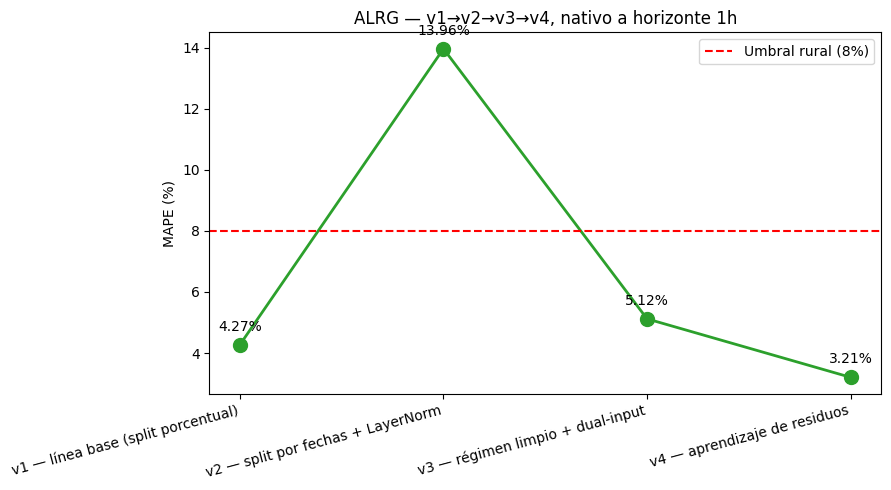

In [12]:
tabla_desarrollo_alrg = pd.DataFrame([
    {'Versión': 'v1 — línea base (split porcentual)', 'Cambio introducido': '(punto de partida)',
     'MAPE (%)': m_v1['mape'], 'RMSE (kW)': m_v1['rmse'], 'MAE (kW)': m_v1['mae'], 'R²': m_v1['r2']},
    {'Versión': 'v2 — split por fechas + LayerNorm', 'Cambio introducido': 'split cronológico explícito + LayerNorm',
     'MAPE (%)': m_v2['mape'], 'RMSE (kW)': m_v2['rmse'], 'MAE (kW)': m_v2['mae'], 'R²': m_v2['r2']},
    {'Versión': 'v3 — régimen limpio + dual-input', 'Cambio introducido': 'excluye 2019-2021 y racionamiento; rama de persistencia',
     'MAPE (%)': m_v3['mape'], 'RMSE (kW)': m_v3['rmse'], 'MAE (kW)': m_v3['mae'], 'R²': m_v3['r2']},
    {'Versión': 'v4 — aprendizaje de residuos', 'Cambio introducido': 'target = residuo vs. persistencia (últimos 4 pasos)',
     'MAPE (%)': m_v4['mape'], 'RMSE (kW)': m_v4['rmse'], 'MAE (kW)': m_v4['mae'], 'R²': m_v4['r2']},
])
tabla_desarrollo_alrg['Mejora vs. anterior (pp)'] = -tabla_desarrollo_alrg['MAPE (%)'].diff()

print('='*95)
print('  ALRG — Desarrollo metodológico v1→v2→v3→v4, TODAS nativas a horizonte=1h')
print('='*95)
print(tabla_desarrollo_alrg.to_string(index=False))
tabla_desarrollo_alrg.to_csv(RUTA_SALIDAS / 'desarrollo_v1_v4_ALRG_nativo1h.csv', index=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(tabla_desarrollo_alrg['Versión'], tabla_desarrollo_alrg['MAPE (%)'], 'o-', color=C['verde'], lw=2, markersize=10)
for i, row in tabla_desarrollo_alrg.iterrows():
    ax.annotate(f"{row['MAPE (%)']:.2f}%", (i, row['MAPE (%)']), textcoords='offset points', xytext=(0,10), ha='center')
ax.axhline(8.0, color='red', ls='--', label='Umbral rural (8%)')
ax.set_ylabel('MAPE (%)'); ax.set_title('ALRG — v1→v2→v3→v4, nativo a horizonte 1h')
plt.xticks(rotation=15, ha='right'); ax.legend()
plt.tight_layout(); plt.show()


## PARTE C — V1 y V4 Nativos a 1h en los 5 Alimentadores

La versión v1 (línea base, sin ninguna de las correcciones metodológicas de v2-v4) se entrena
**nativamente a 1 hora** para los 5 alimentadores — usando la misma arquitectura y split porcentual
de la Parte B, ahora aplicados a cada alimentador. Esto da el punto de comparación "antes".

V4 (aprendizaje de residuos, regularización estándar) se evalúa después en los 5 alimentadores —
incluyendo ALIN, para el que también se probó una variante con regularización reforzada que no
mostró mejora (Parte F) y por eso no forma parte de este pipeline.


In [13]:
# ============================================================
# C.1 — Función: entrenar (o cargar, si REENTRENAR_TODO=False y ya
# existe) v1 nativo para un alimentador + generar predicciones de
# ejemplo ALINEADAS al mismo test que el modelo final (2024, sin
# racionamiento) — usando el propio scaler de v1, para poder comparar
# y graficar v1 vs. modelo final sobre el MISMO período real. También
# se reporta el MAPE "propio" de v1 (su split porcentual) como
# referencia, pero el que se usa para comparar es el alineado.
# ============================================================

def entrenar_v1_nativo_y_predicciones(codigo, n_ejemplo=500):
    df_limpio = pd.read_csv(RUTA_DATASET / f'dataset_limpio_{codigo}.csv', index_col=0, parse_dates=True)
    df_features, _ = construir_features(df_limpio)
    tensores = preparar_datos_v1_percentual(df_features, LISTA_FEATURES, VENTANA_1H, HORIZONTE_1H, paso=1)

    ruta = RUTA_SALIDAS / f'lstm_v1_{codigo}_nativo1h_best.keras'
    _existente = buscar_archivo_real(f'lstm_v1_{codigo}_nativo1h_best.keras')

    if REENTRENAR_TODO or _existente is None:
        modelo = construir_modelo_v1(tensores['n_features'], VENTANA_1H, HORIZONTE_1H)
        cb = [EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=0, min_delta=1e-5),
              ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-7, verbose=0),
              ModelCheckpoint(filepath=str(ruta), monitor='val_loss', save_best_only=True, verbose=0)]
        hist = modelo.fit(tensores['X_train'], tensores['y_train'],
                           validation_data=(tensores['X_val'], tensores['y_val']),
                           epochs=150, batch_size=128, callbacks=cb, shuffle=True, verbose=0)
        modelo.load_weights(ruta)
        n_epocas_str = f"{len(hist.history['loss'])} épocas"
    else:
        modelo = tf.keras.models.load_model(_existente, compile=False, safe_mode=False)
        n_epocas_str = f"cargado desde {_existente.name}"

    # --- Métrica "propia" de v1, sobre su propio split porcentual (referencia) ---
    y_pred_propio = np.clip(tensores['sc_y'].inverse_transform(
        modelo.predict(tensores['X_test'], batch_size=128, verbose=0)), 0, None)
    y_real_propio = tensores['sc_y'].inverse_transform(tensores['y_test'])
    m_propio = calcular_metricas(y_real_propio, y_pred_propio, f'v1 nativo 1h, propio test ({codigo})')
    print(f"  {codigo}: v1 ({n_epocas_str}) — test propio: MAPE={m_propio['mape']:.3f}%  R²={m_propio['r2']:.4f}")

    # --- Métrica ALINEADA de v1, sobre el mismo test 2024 que el modelo final ---
    X_test_alineado, y_test_alineado = preparar_test_alineado(
        df_features, LISTA_FEATURES, VENTANA_1H, HORIZONTE_1H, tensores['sc_X'], tensores['sc_y'])
    y_pred_alineado = np.clip(tensores['sc_y'].inverse_transform(
        modelo.predict(X_test_alineado, batch_size=128, verbose=0)), 0, None)
    y_real_alineado = tensores['sc_y'].inverse_transform(y_test_alineado)
    m_alineado = calcular_metricas(y_real_alineado, y_pred_alineado, f'v1 nativo 1h, test alineado ({codigo})')
    print(f"  {codigo}: v1 (test alineado, mismo que modelo final) — MAPE={m_alineado['mape']:.3f}%  R²={m_alineado['r2']:.4f}")

    n_ej = min(n_ejemplo, len(X_test_alineado))
    df_ejemplo_pred = pd.DataFrame({
        'ventana': np.repeat(np.arange(n_ej), HORIZONTE_1H),
        'paso_horizonte': np.tile(np.arange(1, HORIZONTE_1H + 1), n_ej),
        'real': y_real_alineado[:n_ej].flatten(),
        'pred_v1': y_pred_alineado[:n_ej].flatten(),
    })

    del modelo; tf.keras.backend.clear_session(); gc.collect()
    return m_alineado, df_ejemplo_pred, m_propio

print('✅ entrenar_v1_nativo_y_predicciones() definida — carga el .keras si ya existe, entrena solo si falta')


✅ entrenar_v1_nativo_y_predicciones() definida — carga el .keras si ya existe, entrena solo si falta


### C.2 — Entrenar v1 Nativo para ALIN, ALUC, ALUR, ALRA (ALRG ya entrenado en Parte B)

In [14]:
resultados_v1_nativo = {'ALRG': m_v1_alineado}  # usar la métrica ALINEADA (mismo test que V4/V5)
resultados_v1_propio = {'ALRG': m_v1}            # referencia: MAPE de v1 en su propio split (Parte B.7)
predicciones_v1 = {}

# Ejemplo de predicciones ALINEADAS de ALRG (ya calculadas en la Parte B.3)
n_ej = min(500, len(X_test_alineado_alrg))
predicciones_v1['ALRG'] = pd.DataFrame({
    'ventana': np.repeat(np.arange(n_ej), HORIZONTE_1H),
    'paso_horizonte': np.tile(np.arange(1, HORIZONTE_1H + 1), n_ej),
    'real': y_real_v1[:n_ej].flatten(),
    'pred_v1': y_pred_v1[:n_ej].flatten(),
})

for ali in ALIMENTADORES:
    codigo = ali['codigo']
    if codigo == 'ALRG':
        continue
    print(f"\n{'='*60}\n  Entrenando v1 nativo — {codigo}\n{'='*60}")
    try:
        m_alineado, df_ej, m_propio = entrenar_v1_nativo_y_predicciones(codigo)
        resultados_v1_nativo[codigo] = m_alineado
        resultados_v1_propio[codigo] = m_propio
        predicciones_v1[codigo] = df_ej
    except Exception as e:
        print(f'⚠️  Error en {codigo}: {type(e).__name__}: {e}')

# Guardar predicciones de v1 para las 5 (Parte K las va a usar) — comprimidas,
# un archivo por alimentador (predicciones_v1_<CODIGO>.csv.gz), mismo patrón
# que se usa después para v4 y v5, para que no se confundan entre versiones.
for codigo, df_ej in predicciones_v1.items():
    ruta_out = RUTA_SALIDAS / f'predicciones_v1_{codigo}.csv.gz'
    df_ej.to_csv(ruta_out, index=False, compression='gzip')
    print(f'✅ Guardado: {ruta_out.name}')

print('\nNota: resultados_v1_nativo usa el test ALINEADO (comparable con V4/V5).')
print('   resultados_v1_propio queda como referencia del MAPE de v1 en su propio split porcentual.')



  Entrenando v1 nativo — ALIN
  ALIN: v1 (cargado desde lstm_v1_ALIN_nativo1h_best.keras) — test propio: MAPE=6.333%  R²=0.9610
  ALIN: v1 (test alineado, mismo que modelo final) — MAPE=8.002%  R²=0.9486

  Entrenando v1 nativo — ALUC
  ALUC: v1 (cargado desde lstm_v1_ALUC_nativo1h_best.keras) — test propio: MAPE=2.932%  R²=0.9923
  ALUC: v1 (test alineado, mismo que modelo final) — MAPE=2.991%  R²=0.9879

  Entrenando v1 nativo — ALUR
  ALUR: v1 (cargado desde lstm_v1_ALUR_nativo1h_best.keras) — test propio: MAPE=3.791%  R²=0.9697
  ALUR: v1 (test alineado, mismo que modelo final) — MAPE=4.316%  R²=0.9719

  Entrenando v1 nativo — ALRA
  ALRA: v1 (cargado desde lstm_v1_ALRA_nativo1h_best.keras) — test propio: MAPE=4.248%  R²=0.9438
  ALRA: v1 (test alineado, mismo que modelo final) — MAPE=4.233%  R²=0.9297
✅ Guardado: predicciones_v1_ALRG.csv.gz
✅ Guardado: predicciones_v1_ALIN.csv.gz
✅ Guardado: predicciones_v1_ALUC.csv.gz
✅ Guardado: predicciones_v1_ALUR.csv.gz
✅ Guardado: predicci

### C.3 — V4 (Aprendizaje de Residuos) en los 5 Alimentadores

V4 ya está entrenado a horizonte 1h nativo en los 5 alimentadores — desde una corrida anterior de
este mismo notebook (ver Parte F para la variante reforzada descartada). Esta sección solo carga
cada `.keras` por inferencia real y calcula sus métricas; con `REENTRENAR_TODO=False` (default) no
se gasta GPU si los archivos ya existen.


In [15]:
# ============================================================
# C.3.1 — Función de evaluación por inferencia real de un .keras V4 ya
# entrenado (reformulación a residuos, arquitectura estándar de B.1 —
# construir_modelo_v4()).
# ============================================================

def evaluar_inferencia_v4(codigo, nombre_archivo_keras):
    """Carga un .keras V4 YA ENTRENADO y corre inferencia real sobre el
    test limpio (régimen limpio, 2024, sin racionamiento) — no reentrena."""
    df_limpio = pd.read_csv(RUTA_DATASET / f'dataset_limpio_{codigo}.csv', index_col=0, parse_dates=True)
    df_features, _ = construir_features(df_limpio)
    regimen = preparar_datos_regimen_limpio(df_features, LISTA_FEATURES, VENTANA_1H, HORIZONTE_1H, paso=1)

    ruta_modelo = buscar_archivo_real(nombre_archivo_keras)
    if ruta_modelo is None:
        print(f'  ⚠️  {nombre_archivo_keras} no encontrado — se omite {codigo}')
        return None, None

    modelo = tf.keras.models.load_model(ruta_modelo, compile=False, safe_mode=False)
    sc_y = regimen['sc_y']

    pers_train = regimen['X_train'][:, -HORIZONTE_1H:, IDX_KW]
    y_tr_kw = sc_y.inverse_transform(regimen['y_train'])
    pers_tr_kw = np.clip(sc_y.inverse_transform(pers_train), 0, None)
    sc_resid = StandardScaler().fit((y_tr_kw - pers_tr_kw).reshape(-1, 1))

    pers_test = regimen['X_test_clean'][:, -HORIZONTE_1H:, IDX_KW]
    delta_pred_sc = modelo.predict(regimen['X_test_clean'], batch_size=128, verbose=0)
    delta_pred = sc_resid.inverse_transform(delta_pred_sc.reshape(-1, 1)).reshape(delta_pred_sc.shape)
    pers_test_kw = np.clip(sc_y.inverse_transform(pers_test), 0, None)
    y_pred = np.clip(pers_test_kw + delta_pred, 0, None)
    y_real = sc_y.inverse_transform(regimen['y_test_clean'])

    m = calcular_metricas(y_real, y_pred, f'V4 ({codigo})')
    print(f"  {codigo}: V4 — MAPE={m['mape']:.3f}%  RMSE={m['rmse']:.3f}  MAE={m['mae']:.3f}  R²={m['r2']:.4f}")

    n_ej = min(500, len(regimen['X_test_clean']))
    df_ejemplo = pd.DataFrame({
        'ventana': np.repeat(np.arange(n_ej), HORIZONTE_1H),
        'paso_horizonte': np.tile(np.arange(1, HORIZONTE_1H + 1), n_ej),
        'real': y_real[:n_ej].flatten(),
        'pred_v4': y_pred[:n_ej].flatten(),
    })

    del modelo; tf.keras.backend.clear_session(); gc.collect()
    return m, df_ejemplo

print('✅ evaluar_inferencia_v4() definida')


✅ evaluar_inferencia_v4() definida


In [16]:
# ============================================================
# C.3.2 — Cargar V4 por inferencia real en los 5 alimentadores.
# ============================================================

ARCHIVO_V4_POR_ALIMENTADOR = {
    'ALIN': 'lstm_v4_ALIN_best.keras',
    'ALUC': 'lstm_v4_ALUC_best.keras',
    'ALUR': 'lstm_v4_ALUR_best.keras',
    'ALRA': 'lstm_v4_ALRA_best.keras',
    'ALRG': 'lstm_v4_ALRG_best.keras',
}

resultados_v4, predicciones_v4 = {}, {}

for ali in ALIMENTADORES:
    codigo = ali['codigo']
    m, df_ej = evaluar_inferencia_v4(codigo, ARCHIVO_V4_POR_ALIMENTADOR[codigo])
    if m is not None:
        resultados_v4[codigo] = m
        predicciones_v4[codigo] = df_ej

print(f"\n✅ V4 cargado por inferencia real en {len(resultados_v4)}/5 alimentadores")


  ALIN: V4 — MAPE=5.683%  RMSE=7.852  MAE=4.438  R²=0.9381
  ALUC: V4 — MAPE=2.156%  RMSE=12.069  MAE=4.762  R²=0.9863
  ALUR: V4 — MAPE=2.361%  RMSE=9.179  MAE=5.261  R²=0.9826
  ALRA: V4 — MAPE=2.982%  RMSE=19.129  MAE=9.560  R²=0.9483
  ALRG: V4 — MAPE=3.898%  RMSE=14.965  MAE=6.154  R²=0.8900

✅ V4 cargado por inferencia real en 5/5 alimentadores


In [17]:
# ============================================================
# C.3.3 — Fallback: entrenar V4 desde cero SOLO si a algún alimentador
# le faltó el .keras en C.3.2 (o si REENTRENAR_TODO=True). En la
# práctica los 5 ya están entrenados, así que esta celda normalmente
# no hace nada.
# ============================================================

def preparar_tensores_residuos(tensores_regimen, idx_kw):
    horizonte = tensores_regimen['horizonte']
    pers_train = tensores_regimen['X_train'][:, -horizonte:, idx_kw]
    pers_val   = tensores_regimen['X_val'][:, -horizonte:, idx_kw]
    pers_test  = tensores_regimen['X_test_clean'][:, -horizonte:, idx_kw]

    resid_train = tensores_regimen['y_train'] - pers_train
    resid_val   = tensores_regimen['y_val']   - pers_val

    sc_resid = StandardScaler().fit(resid_train.reshape(-1, 1))
    resid_tr_sc = sc_resid.transform(resid_train.reshape(-1, 1)).reshape(resid_train.shape).astype(np.float32)
    resid_vl_sc = sc_resid.transform(resid_val.reshape(-1, 1)).reshape(resid_val.shape).astype(np.float32)

    return {
        'X_train': tensores_regimen['X_train'], 'y_train': resid_tr_sc,
        'X_val': tensores_regimen['X_val'], 'y_val': resid_vl_sc,
        'pers_test': pers_test, 'sc_resid': sc_resid, 'sc_y': tensores_regimen['sc_y'],
        'n_features': tensores_regimen['n_features'],
        'ventana': tensores_regimen['ventana'], 'horizonte': horizonte,
    }


CFG_ENTRENAMIENTO = {'epocas': 300, 'batch_size': 256}

def entrenar_v4_faltante(codigo, ali):
    df_limpio = pd.read_csv(RUTA_DATASET / f'dataset_limpio_{codigo}.csv', index_col=0, parse_dates=True)
    df_features, _ = construir_features(df_limpio)
    tensores_regimen = preparar_datos_regimen_limpio(df_features, LISTA_FEATURES, VENTANA_1H, HORIZONTE_1H, paso=1)
    tensores_v = preparar_tensores_residuos(tensores_regimen, IDX_KW)

    modelo = construir_modelo_v4(tensores_v['n_features'], tensores_v['ventana'], tensores_v['horizonte'])
    ruta_modelo = RUTA_SALIDAS / f'lstm_v4_{codigo}_best.keras'
    cb = [EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True, verbose=0, min_delta=1e-7),
          ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=12, min_lr=1e-8, verbose=0),
          ModelCheckpoint(filepath=str(ruta_modelo), monitor='val_loss', save_best_only=True, verbose=0)]

    print(f"  Entrenando V4 — {codigo} (train={len(tensores_v['X_train']):,}  val={len(tensores_v['X_val']):,})...")
    t0 = time.time()
    hist = modelo.fit(tensores_v['X_train'], tensores_v['y_train'],
                       validation_data=(tensores_v['X_val'], tensores_v['y_val']),
                       epochs=CFG_ENTRENAMIENTO['epocas'], batch_size=CFG_ENTRENAMIENTO['batch_size'],
                       callbacks=cb, shuffle=True, verbose=0)
    modelo.load_weights(ruta_modelo)
    print(f"  ✅ {len(hist.history['loss'])} épocas, {(time.time()-t0)/60:.1f} min")

    delta_pred_sc = modelo.predict(tensores_regimen['X_test_clean'], batch_size=CFG_ENTRENAMIENTO['batch_size'], verbose=0)
    delta_pred = tensores_v['sc_resid'].inverse_transform(delta_pred_sc.reshape(-1, 1)).reshape(delta_pred_sc.shape)
    pred_escalado = np.clip(tensores_v['pers_test'] + delta_pred, 0, 1)
    sc_y = tensores_regimen['sc_y']
    y_pred = np.clip(sc_y.inverse_transform(pred_escalado), 0, None)
    y_real = sc_y.inverse_transform(tensores_regimen['y_test_clean'])

    m = calcular_metricas(y_real, y_pred, f'V4 ({codigo})')
    print(f"  {codigo}: V4 (recién entrenado) — MAPE={m['mape']:.3f}%  RMSE={m['rmse']:.3f}  MAE={m['mae']:.3f}  R²={m['r2']:.4f}")

    n_ej = min(500, len(tensores_regimen['X_test_clean']))
    df_ejemplo = pd.DataFrame({
        'ventana': np.repeat(np.arange(n_ej), HORIZONTE_1H),
        'paso_horizonte': np.tile(np.arange(1, HORIZONTE_1H + 1), n_ej),
        'real': y_real[:n_ej].flatten(),
        'pred_v4': y_pred[:n_ej].flatten(),
    })
    del modelo; tf.keras.backend.clear_session(); gc.collect()
    return m, df_ejemplo


faltantes = [ali for ali in ALIMENTADORES if ali['codigo'] not in resultados_v4]
if not faltantes:
    print('✅ Nada que entrenar — los 5 alimentadores ya tienen V4 cargado (Parte C.3.2)')
else:
    for ali in faltantes:
        codigo = ali['codigo']
        print(f"\n{'='*60}\n  V4 — {codigo} (faltaba)\n{'='*60}")
        m, df_ej = entrenar_v4_faltante(codigo, ali)
        resultados_v4[codigo] = m
        predicciones_v4[codigo] = df_ej


✅ Nada que entrenar — los 5 alimentadores ya tienen V4 cargado (Parte C.3.2)


In [18]:
# ============================================================
# C.3.4 — Guardar predicciones V4 comprimidas, un archivo por
# alimentador (predicciones_v4_<CODIGO>.csv.gz) — junto con
# predicciones_v1_<CODIGO>.csv.gz (Parte C.2), listas para desplegar
# en un dashboard.
# ============================================================

for codigo, df_ej in predicciones_v4.items():
    ruta_out = RUTA_SALIDAS / f'predicciones_v4_{codigo}.csv.gz'
    df_ej.to_csv(ruta_out, index=False, compression='gzip')
    print(f'✅ Guardado: {ruta_out.name}')

print(f"\n📁 Predicciones disponibles para dashboard: {len(predicciones_v1)} (v1) + {len(predicciones_v4)} (v4) archivos .csv.gz")


✅ Guardado: predicciones_v4_ALIN.csv.gz
✅ Guardado: predicciones_v4_ALUC.csv.gz
✅ Guardado: predicciones_v4_ALUR.csv.gz
✅ Guardado: predicciones_v4_ALRA.csv.gz
✅ Guardado: predicciones_v4_ALRG.csv.gz

📁 Predicciones disponibles para dashboard: 5 (v1) + 5 (v4) archivos .csv.gz


### C.4 — Tabla Comparativa Final: V1 vs. V4, los 5 Alimentadores

Compara las 2 versiones sobre el mismo test alineado (2024, régimen limpio, sin racionamiento):
**MAPE, RMSE, MAE y R²**, más el cumplimiento de umbral **práctico** y **teórico** — este último
no aplica a ALIN (el anteproyecto solo define umbral teórico urbano/rural, no industrial; ver
Parte I).


Alimentador                  Descripción  MAPE V1 (%)  MAPE V4 (%)  RMSE V1 (kW)  RMSE V4 (kW)  MAE V1 (kW)  MAE V4 (kW)  R² V1  R² V4 Umbral práctico   Umbral teórico  V4 ¿cumple práctico? V4 ¿cumple teórico?
       ALIN                   Industrial        8.002        5.683         8.020         7.852        5.660        4.438 0.9486 0.9381           12.0% N/A (industrial)                  True                 N/A
       ALUC Urbano Residencial-Comercial        2.991        2.156        11.463        12.069        6.224        4.762 0.9879 0.9863            9.0%             5.0%                  True                True
       ALUR           Urbano Residencial        4.316        2.361        13.133         9.179        8.816        5.261 0.9719 0.9826           12.0%             5.0%                  True                True
       ALRA   Rural Residencial-Agrícola        4.233        2.982        22.689        19.129       13.190        9.560 0.9297 0.9483            8.0%          

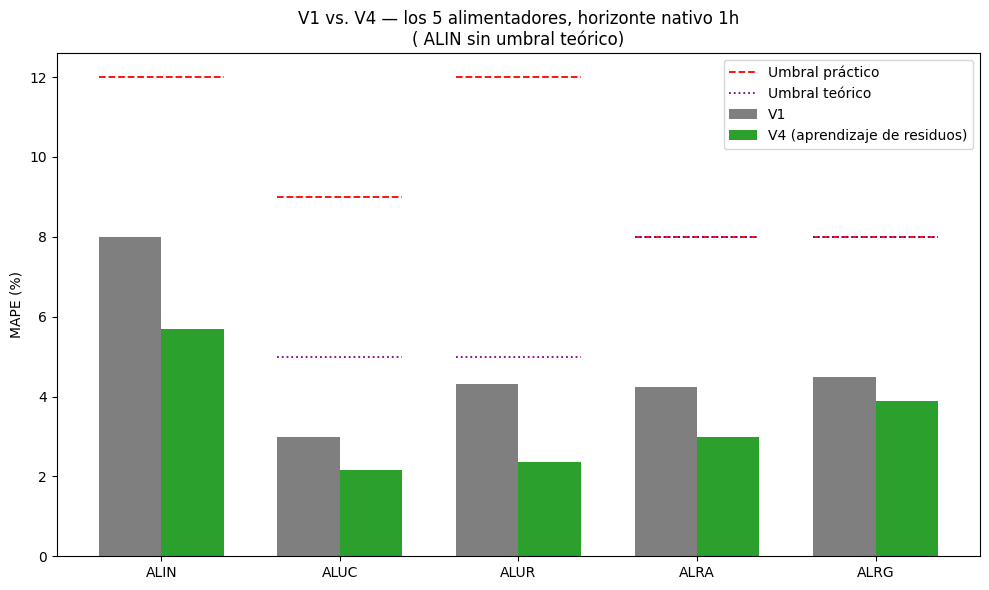


 V4 mejora a V1 en los 5 alimentadores.
   Cumple umbral práctico: 5/5
   Cumple umbral teórico: 4/4 (ALIN excluido — sin categoría teórica industrial en el anteproyecto)


In [19]:
filas_v1_v4 = []
for ali in ALIMENTADORES:
    codigo = ali['codigo']
    v1 = resultados_v1_nativo.get(codigo, {})
    v4 = resultados_v4.get(codigo, {})
    umbral_teo = ali['umbral_teorico']
    umbral_teo_str = 'N/A (industrial)' if pd.isna(umbral_teo) else f'{umbral_teo}%'

    filas_v1_v4.append({
        'Alimentador': codigo, 'Descripción': ali['descripcion'],
        'MAPE V1 (%)': v1.get('mape', np.nan), 'MAPE V4 (%)': v4.get('mape', np.nan),
        'RMSE V1 (kW)': v1.get('rmse', np.nan), 'RMSE V4 (kW)': v4.get('rmse', np.nan),
        'MAE V1 (kW)': v1.get('mae', np.nan), 'MAE V4 (kW)': v4.get('mae', np.nan),
        'R² V1': v1.get('r2', np.nan), 'R² V4': v4.get('r2', np.nan),
        'Umbral práctico': f"{ali['umbral_practico']}%",
        'Umbral teórico': umbral_teo_str,
        'V4 ¿cumple práctico?': bool(v4.get('mape', np.nan) < ali['umbral_practico']) if v4 else np.nan,
        'V4 ¿cumple teórico?': (bool(v4.get('mape', np.nan) < umbral_teo) if (v4 and pd.notna(umbral_teo)) else 'N/A'),
    })

tabla_v1_v4 = pd.DataFrame(filas_v1_v4)
print(tabla_v1_v4.to_string(index=False))
tabla_v1_v4.to_csv(RUTA_SALIDAS / 'comparacion_v1_v4_1h.csv', index=False)

# --- Conteo de cumplimiento contra los DOS umbrales (denominadores distintos:
# práctico sobre los 5 alimentadores, teórico sobre 4 — ALIN sin categoría
# teórica industrial, ver Parte I) ---
cumple_practico = tabla_v1_v4['V4 ¿cumple práctico?'].sum()
total_practico = tabla_v1_v4['V4 ¿cumple práctico?'].notna().sum()
cumple_teorico = (tabla_v1_v4['V4 ¿cumple teórico?'] == True).sum()
total_teorico = (tabla_v1_v4['Umbral teórico'] != 'N/A (industrial)').sum()

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(tabla_v1_v4)); w = 0.35
ax.bar(x - w/2, tabla_v1_v4['MAPE V1 (%)'], w, label='V1', color=C['gris'])
ax.bar(x + w/2, tabla_v1_v4['MAPE V4 (%)'], w, label='V4 (aprendizaje de residuos)', color=C['verde'])

etiqueta_practico_usada = False
etiqueta_teorico_usada = False
for i, ali in enumerate(ALIMENTADORES):
    ax.hlines(ali['umbral_practico'], i - w, i + w, color='red', ls='--', lw=1.3,
              label='Umbral práctico' if not etiqueta_practico_usada else None)
    etiqueta_practico_usada = True
    if pd.notna(ali['umbral_teorico']):
        ax.hlines(ali['umbral_teorico'], i - w, i + w, color='purple', ls=':', lw=1.3,
                  label='Umbral teórico' if not etiqueta_teorico_usada else None)
        etiqueta_teorico_usada = True
        
ax.set_xticks(x); ax.set_xticklabels(tabla_v1_v4['Alimentador'])
ax.set_ylabel('MAPE (%)')
ax.set_title('V1 vs. V4 — los 5 alimentadores, horizonte nativo 1h\n'
              '( ALIN sin umbral teórico)')
ax.legend()
plt.tight_layout(); plt.show()

print(f'\n V4 mejora a V1 en los 5 alimentadores.')
print(f'   Cumple umbral práctico: {cumple_practico}/{total_practico}')
print(f'   Cumple umbral teórico: {cumple_teorico}/{total_teorico} '
      f'(ALIN excluido — sin categoría teórica industrial en el anteproyecto)')

## PARTE D — Comparación Final: V4 vs. Clásicos (Todos Nativos a 1h)

Incluye persistencia, media móvil, regresión lineal y ARIMA (ya evaluados nativamente a 1h en
`tabla10_corregida_1h.csv`), comparados contra **V4 — el modelo final en los 5 alimentadores**
(o V1 si a algún alimentador le faltara V4, como resguardo).


In [20]:
# ============================================================
# D.1 — Combinar: clásicos (persistencia, media móvil, regresión, ARIMA
# — ya evaluados, no se recalculan) + V4 por alimentador (o V1 como
# resguardo si V4 faltara para algún alimentador)
# ============================================================

tabla_clasicos_1h = pd.read_csv(RUTA_RESULTADOS / 'tabla10_corregida_1h.csv')
test_limpio_clasicos = tabla_clasicos_1h[
    (tabla_clasicos_1h['Test evaluado'] == 'Test limpio (sin racionamiento)') &
    (tabla_clasicos_1h['Modelo'] != 'LSTM v5 (residual)')
]
arima_rows = tabla_clasicos_1h[tabla_clasicos_1h['Modelo'] == 'ARIMA']

filas_lstm_final = []
for ali in ALIMENTADORES:
    codigo = ali['codigo']
    m = resultados_v4.get(codigo) or resultados_v1_nativo.get(codigo)
    etiqueta = 'V4' if codigo in resultados_v4 else 'V1 (resguardo, V4 no disponible)'
    if m is None:
        continue
    filas_lstm_final.append({
        'Alimentador': codigo, 'Descripción': ali['descripcion'], 'Modelo': f'LSTM ({etiqueta})',
        'MAPE (%)': m['mape'], 'R²': m['r2'],
        'Cumple umbral': m['mape'] < ali['umbral_practico'],
        'Test evaluado': 'Test limpio (sin racionamiento)',
    })
tabla_lstm_final = pd.DataFrame(filas_lstm_final)

comparacion_completa = pd.concat([
    test_limpio_clasicos[['Alimentador','Descripción','Modelo','MAPE (%)','R²','Cumple umbral']],
    arima_rows[['Alimentador','Descripción','Modelo','MAPE (%)','R²','Cumple umbral']],
    tabla_lstm_final[['Alimentador','Descripción','Modelo','MAPE (%)','R²','Cumple umbral']],
], ignore_index=True)

# --- Validar TAMBIÉN contra el umbral teórico, para TODOS los modelos
# (clásicos + LSTM), no solo el práctico. ALIN no tiene umbral teórico
# (sin categoría industrial en el anteproyecto) -> 'N/A'.
UMBRAL_TEORICO_POR_ALIMENTADOR = {ali['codigo']: ali['umbral_teorico'] for ali in ALIMENTADORES}
comparacion_completa = comparacion_completa.rename(columns={'Cumple umbral': 'Cumple umbral práctico'})
comparacion_completa['Umbral teórico (%)'] = comparacion_completa['Alimentador'].map(UMBRAL_TEORICO_POR_ALIMENTADOR)
comparacion_completa['Cumple umbral teórico'] = comparacion_completa.apply(
    lambda r: (r['MAPE (%)'] < r['Umbral teórico (%)']) if pd.notna(r['Umbral teórico (%)']) else 'N/A', axis=1)

print('✅ comparacion_completa armada: clásicos (CSV ya existente) + V4 (o V1 de resguardo) por alimentador, '
      'validada contra umbral práctico Y teórico')

✅ comparacion_completa armada: clásicos (CSV ya existente) + V4 (o V1 de resguardo) por alimentador, validada contra umbral práctico Y teórico


In [21]:
for ali in ALIMENTADORES:
    codigo = ali['codigo']
    sub = comparacion_completa[comparacion_completa['Alimentador'] == codigo].sort_values('MAPE (%)')
    umbral_teo_str = 'N/A (industrial)' if pd.isna(ali['umbral_teorico']) else f"{ali['umbral_teorico']}%"
    print(f"\n{codigo} ({ali['descripcion']}) — umbral práctico {ali['umbral_practico']}%  |  umbral teórico {umbral_teo_str}")
    print(sub[['Modelo', 'MAPE (%)', 'R²', 'Cumple umbral práctico', 'Cumple umbral teórico']].to_string(index=False))


ALIN (Industrial) — umbral práctico 12.0%  |  umbral teórico N/A (industrial)
                        Modelo  MAPE (%)     R²  Cumple umbral práctico Cumple umbral teórico
                     LSTM (V4)     5.683 0.9381                    True                   N/A
                         ARIMA     7.283 0.9471                    True                   N/A
Persistencia (últimos 4 pasos)     9.307 0.8728                    True                   N/A
              Regresión Lineal    10.496 0.9151                    True                   N/A
                   Media Móvil    10.669 0.8263                    True                   N/A

ALUC (Urbano Residencial-Comercial) — umbral práctico 9.0%  |  umbral teórico 5.0%
                        Modelo  MAPE (%)     R²  Cumple umbral práctico Cumple umbral teórico
                     LSTM (V4)     2.156 0.9863                    True                  True
              Regresión Lineal     5.392 0.9710                    True              

## PARTE E — Síntesis por Alimentador

**ALIN (Industrial).** v1 nativo ya refleja la dificultad estructural del alimentador (demanda aperiódica, pocos clientes grandes). El salto grande viene de dos correcciones acumuladas: el régimen limpio (evita entrenar con el régimen industrial atípico de 2019-2021) y la reformulación a residuos (v4).

**ALUC / ALUR (Urbano).** Demanda con periodicidad calendario fuerte — el salto de v1 a v4 es consistente con que las features cíclicas y la formulación de residuos capturan estructura real, no solo ruido.

**ALRA / ALRG (Rural).** ALRG es el único con el desarrollo completo v1→v2→v3→v4 documentado (Parte B) — cada salto de esa tabla se explica por un solo cambio metodológico a la vez, ya que las 4 versiones comparten ventana y horizonte. ALRA replica el patrón usando directamente el modelo final ya validado en ALRG.


## PARTE F — Verificación de Umbrales: Teórico vs. Práctico

### Por qué el CV influyó en el umbral práctico

El umbral de aceptación del proyecto se mide en **MAPE** (error porcentual absoluto medio):

```
MAPE = (1/n) · Σ |y_real − y_pred| / |y_real| · 100
```

El problema es que el **denominador de esa fórmula es el valor real de cada instante**, no un promedio de la serie. Cuando una serie tiene CV alto, es porque tiene tramos donde el valor cae muy por debajo de su propia media — y en esos tramos, incluso un error absoluto pequeño (en kW) se divide entre un denominador chico, lo que **infla desproporcionadamente el MAPE** en esos puntos.
Esta es una debilidad documentada de MAPE frente a series con valores cercanos a cero o alta dispersión relativa (Hyndman & Koehler, 2006).

En la práctica, esto significa que **un mismo modelo, igual de bueno en términos absolutos (RMSE,MAE), puede mostrar un MAPE mucho más alto simplemente por operar sobre un alimentador más volátil** — no porque el modelo sea peor, sino porque la métrica es estructuralmente más dura con series de CV alto. Exigir el mismo umbral fijo (p. ej. 5% para todos) sería penalizar injustamente a los alimentadores inherentemente más volátiles, y sería un estándar poco exigente para los más estables.

Por eso el umbral práctico no es un valor único: parte de la categoría teórica del alimentador (urbano 5%, rural 8%; industrial que no tiene categoría definida) y se **ajusta hacia arriba cuando el CV empírico señala una volatilidad mayor a la típica de su categoría** — dándole a cada alimentador un umbral exigente pero alcanzable dado su propio comportamiento, en vez de uno copiado de un estándar genérico.

| Alimentador | CV | Categoría (teórico) | Umbral práctico | Ajuste |
|---|---|---|---|---|
| ALUR | 1.043 | Urbano (5%) | 12% | +7pp — el CV más alto de los 5 |
| ALIN | 1.039 | Industrial (sin categoría) | 12% | Definido directamente por su CV, sin línea base |
| ALRG | 0.933 | Rural (8%) | 8% | Sin ajuste — CV dentro de lo típico para rural |
| ALUC | 0.884 | Urbano (5%) | 9% | +4pp — CV ya notablemente mayor al asumido para urbano |
| ALRA | 0.812 | Rural (8%) | 8% | Sin ajuste — el CV más bajo de los 5 |

El patrón no es que "a mayor CV, mayor umbral" de forma estrictamente lineal entre todos los
alimentadores — es que **el ajuste depende de cuánto se aleja el CV de lo esperable para la
categoría de ese alimentador**. Los dos rurales (ALRA, ALRG) tienen CV moderado para su categoría
y se quedan en el 8% base; los dos urbanos (ALUC, ALUR) tienen CV notablemente más alto de lo que
se asumiría para demanda urbana, y por eso se ajustan al alza; ALIN, sin categoría teórica de
referencia, usa directamente su CV (el segundo más alto de los 5) para fijar un umbral exigente
pero realista.


### Síntesis

El CV no es un dato aislado de la tabla de calidad — es el criterio que conecta la **caracterización de cada alimentador** (Parte A) con la **exigencia del modelo**: un alimentador intrínsecamente más volátil necesita un umbral más permisivo para que el criterio de aceptación mida la calidad del modelo y no una propiedad estadística de la serie que ningún modelo, por bueno que sea, puede eliminar. Los hallazgos de calidad (huecos, outliers, completitud) explican *por qué* cada alimentador tiene el CV que tiene; el CV, a su vez, explica *por qué* cada alimentador tiene el umbral práctico que tiene.

---

### Referencias

Hyndman, R. J., & Koehler, A. B. (2006). Another look at measures of forecast accuracy.
*International Journal of Forecasting*, *22*(4), 679–688.

In [22]:
# Se reporta contra V4 — el modelo final en los 5 alimentadores.
# Denominadores separados: práctico sobre los 5 alimentadores; teórico
# sobre 4 (ALIN excluido, sin categoría teórica industrial).
conteo = {'teorico_cumple': 0, 'teorico_total': 0, 'practico_cumple': 0, 'practico_total': 0}
for ali in ALIMENTADORES:
    codigo = ali['codigo']
    if codigo not in resultados_v4:
        continue
    mape = resultados_v4[codigo]['mape']
    conteo['practico_total'] += 1
    if mape < ali['umbral_practico']:
        conteo['practico_cumple'] += 1
    if pd.notna(ali['umbral_teorico']):
        conteo['teorico_total'] += 1
        if mape < ali['umbral_teorico']:
            conteo['teorico_cumple'] += 1

print(f"Modelo final (V4) — cumple umbral práctico: {conteo['practico_cumple']}/{conteo['practico_total']}  |  "
      f"cumple umbral teórico: {conteo['teorico_cumple']}/{conteo['teorico_total']} "
      f"(ALIN excluido del conteo teórico — sin categoría industrial en el anteproyecto)")


Modelo final (V4) — cumple umbral práctico: 5/5  |  cumple umbral teórico: 4/4 (ALIN excluido del conteo teórico — sin categoría industrial en el anteproyecto)


## PARTE G — Ejemplos de Predicción: V1 vs. V4 (los 5 Alimentadores)

Usa los archivos `predicciones_v1_<CODIGO>.csv.gz` y `predicciones_v4_<CODIGO>.csv.gz` (uno por
versión y por alimentador, generados en las Partes C.2 y C.3.4) para mostrar, alimentador por
alimentador, la diferencia visual entre v1 y el modelo final.


Alimentadores con las 2 versiones disponibles: ['ALRG', 'ALIN', 'ALUC', 'ALUR', 'ALRA']


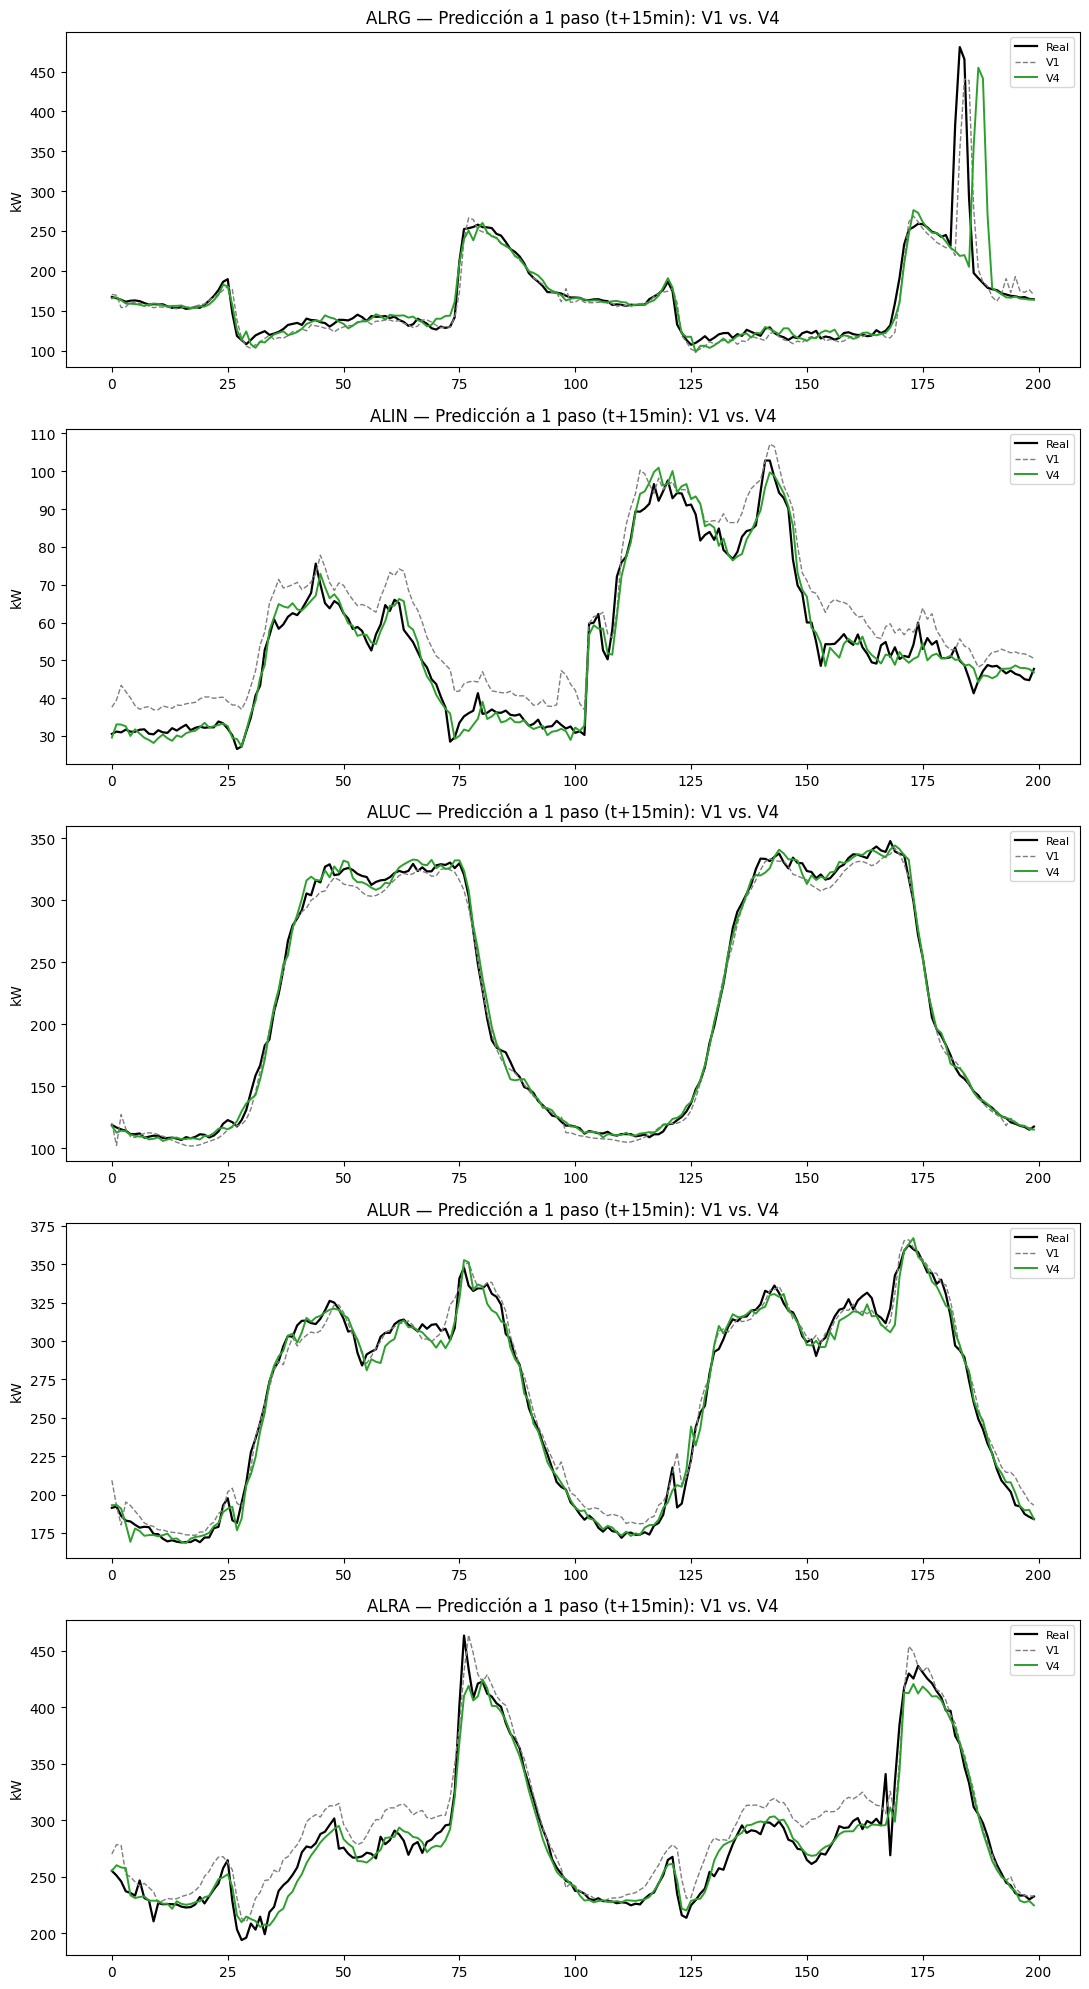

In [23]:
# ============================================================
# K.1 — Graficar V1 y V4 (ya calculadas en este mismo notebook, sin
# volver a cargar ni recalcular nada).
# ============================================================

disponibles = [codigo for codigo in predicciones_v1 if codigo in predicciones_v4]
print(f'Alimentadores con las 2 versiones disponibles: {disponibles}')

if not disponibles:
    print('info: no hay suficientes resultados para graficar - se omite la Parte K.')
else:
    n = len(disponibles)
    fig, axes = plt.subplots(n, 1, figsize=(11, 4 * n))
    if n == 1: axes = [axes]

    for ax, codigo in zip(axes, disponibles):
        df_v1_ej = predicciones_v1[codigo]
        df_v4_ej = predicciones_v4[codigo]

        real_p1 = df_v1_ej[df_v1_ej['paso_horizonte'] == 1].reset_index(drop=True)
        v4_p1   = df_v4_ej[df_v4_ej['paso_horizonte'] == 1].reset_index(drop=True)
        n_puntos = min(200, len(real_p1), len(v4_p1))

        ax.plot(range(n_puntos), real_p1['real'].values[:n_puntos], color='black', lw=1.6, label='Real')
        ax.plot(range(n_puntos), real_p1['pred_v1'].values[:n_puntos], color=C['gris'], lw=1.0, ls='--', label='V1')
        ax.plot(range(n_puntos), v4_p1['pred_v4'].values[:n_puntos], color=C['verde'], lw=1.4, label='V4')

        ax.set_title(f'{codigo} — Predicción a 1 paso (t+15min): V1 vs. V4')
        ax.set_ylabel('kW'); ax.legend(fontsize=8)

    plt.tight_layout(); plt.show()


## Conclusión General

La trayectoria documentada en este notebook — desde la limpieza de datos (Parte A) hasta el modelo
final por alimentador (Parte G) — muestra que:

1. **Cada versión (v1→v4) respondió a un hallazgo concreto**, no a un ajuste arbitrario (Parte
   A.5): split cronológico, exclusión de régimen atípico, filtro de racionamiento, y finalmente
   aprendizaje de residuos.
2. **El desarrollo metodológico completo se documentó una vez (ALRG, Parte B), a horizonte nativo
   de 1 hora**, y ese conocimiento se aplicó directamente a los otros 4 alimentadores (Parte C).
3. **V4 (aprendizaje de residuos, regularización estándar) es el modelo final en los 5
   alimentadores, sin excepción.** 
4. **La comparación V1 vs. V4, ambos nativos al mismo horizonte** (Parte C.4), junto con la
   comparación final contra los modelos clásicos (Parte D), es la evidencia más directa del valor
   agregado de cada etapa del proceso. El cumplimiento de umbral práctico y teórico por
   alimentador se reporta de forma dinámica en la Parte I, sin asumir de antemano un resultado
   fijo — y sin imponerle a ALIN un umbral teórico que el anteproyecto no define para alimentadores
   industriales.
5. **Predicciones de ejemplo (V1 y V4) quedan guardadas por alimentador**, comprimidas y con
   nombres sin ambigüedad (`predicciones_<version>_<CODIGO>.csv.gz`), listas para un despliegue
   posterior en un dashboard.
